In [1]:
# Cox survival analysis for 2012.03 Cluster 1
# This notebook is standalone. It only needs:
# 1. the original CSV file
# 2. period_state_assignments.csv from the clustering workflow

from pathlib import Path
import math
import numpy as np
import pandas as pd


In [2]:
%conda install -c conda-forge scikit-survival -y

Jupyter detected...
2 channel Terms of Service accepted
Retrieving notices: done
Channels:
 - conda-forge
 - defaults
Platform: osx-arm64
Solving environment: done


==> WARNING: A newer version of conda exists. <==
    current version: 26.1.1
    latest version: 26.5.3

Please update conda by running

    $ conda update -n base -c defaults conda



# All requested packages already installed.


Note: you may need to restart the kernel to use updated packages.


In [3]:
from sksurv.ensemble import RandomSurvivalForest

print("scikit-survival installed successfully!")

scikit-survival installed successfully!


In [4]:
# User settings

csv_path = Path("masterDataOptimal_v220230323015634.csv")
state_path = Path("period_transition_custom_params_results/period_state_assignments.csv")

output_dir = Path("cox_survival_analysis_2012_cluster1_results")
output_dir.mkdir(parents=True, exist_ok=True)

baseline_date = pd.Timestamp("2012-03-01")
followup_end_date = pd.Timestamp("2022-03-01")

source_period = "before_2012_03"
source_cluster = "Cluster 1"

print("CSV:", csv_path)
print("State file:", state_path)
print("Output dir:", output_dir)


CSV: masterDataOptimal_v220230323015634.csv
State file: period_transition_custom_params_results/period_state_assignments.csv
Output dir: cox_survival_analysis_2012_cluster1_results


In [5]:
# Safe CSV writer
# If a CSV file is open in Excel/WPS, Windows may block overwriting it.
# safe_to_csv automatically writes a timestamped copy in that case.

def safe_to_csv(df, path, **kwargs):
    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)
    if "index" not in kwargs:
        kwargs["index"] = False
    if "encoding" not in kwargs:
        kwargs["encoding"] = "utf-8-sig"
    try:
        df.to_csv(path, **kwargs)
        return path
    except PermissionError:
        timestamp = pd.Timestamp.now().strftime("%Y%m%d_%H%M%S")
        fallback_path = path.with_name(f"{path.stem}_{timestamp}{path.suffix}")
        df.to_csv(fallback_path, **kwargs)
        print(f"Permission denied for {path}. Saved timestamped copy instead: {fallback_path}")
        return fallback_path


In [6]:
# Select participants who were in Cluster 1 at 2012.03

state_df = pd.read_csv(state_path)

cluster_rows = state_df.loc[
    state_df[source_period] == source_cluster,
    "original_row_index",
].astype(int).to_numpy()

cluster_row_set = set(cluster_rows.tolist())

print(f"Selected {source_period} {source_cluster} participants: {len(cluster_rows):,}")
state_df[source_period].value_counts(dropna=False)


Selected before_2012_03 Cluster 1 participants: 14,406


before_2012_03
Cluster 3    59755
Cluster 6    22344
Cluster 1    14406
Death        13718
Dropout      12247
Cluster 4     1012
Cluster 5      917
Cluster 2      891
Name: count, dtype: int64

In [7]:
# Identify disease columns and paired diagnosis-date columns

all_cols = pd.read_csv(csv_path, nrows=0).columns.tolist()

b_cols = [c for c in all_cols if c.startswith("B_MEDI:")]
disease_pairs = []

for b_col in b_cols:
    feature_name = b_col.replace("B_MEDI:", "", 1)
    bd_col = "BD_MEDI:" + feature_name
    if bd_col in all_cols:
        disease_pairs.append((b_col, bd_col, feature_name))

print("Paired disease/date features:", len(disease_pairs))
disease_pairs[:5]


Paired disease/date features: 73


[('B_MEDI:HF_BHAM_CAM_FINAL:0',
  'BD_MEDI:HF_BHAM_CAM_FINAL:0',
  'HF_BHAM_CAM_FINAL:0'),
 ('B_MEDI:AF_BHAM_CAM:1', 'BD_MEDI:AF_BHAM_CAM:1', 'AF_BHAM_CAM:1'),
 ('B_MEDI:ISCHAEMICSTROKE_BHAM_CAM:2',
  'BD_MEDI:ISCHAEMICSTROKE_BHAM_CAM:2',
  'ISCHAEMICSTROKE_BHAM_CAM:2'),
 ('B_MEDI:STROKEUNSPECIFIED_BHAM_CAM:3',
  'BD_MEDI:STROKEUNSPECIFIED_BHAM_CAM:3',
  'STROKEUNSPECIFIED_BHAM_CAM:3'),
 ('B_MEDI:STROKE_HAEMRGIC_BHAM_CAM:4',
  'BD_MEDI:STROKE_HAEMRGIC_BHAM_CAM:4',
  'STROKE_HAEMRGIC_BHAM_CAM:4')]

In [8]:
# Load only selected Cluster 1 rows from the original CSV
# B_MEDI columns are not literal 0/1: non-missing means disease code exists.
# BD_MEDI columns store diagnosis dates.

usecols = ["DEATH_DATE", "TRANSFER_DATE", "YEAR_OF_BIRTH", "SEX"]
usecols += [col for pair in disease_pairs for col in pair[:2]]

def skip_non_cluster_rows(line_no):
    if line_no == 0:
        return False
    original_row_index = line_no - 1
    return original_row_index not in cluster_row_set

cluster_df = pd.read_csv(
    csv_path,
    usecols=usecols,
    skiprows=skip_non_cluster_rows,
    low_memory=False,
)

print("Loaded shape:", cluster_df.shape)
cluster_df.head()


Loaded shape: (14406, 150)


,DEATH_DATE,YEAR_OF_BIRTH,SEX,TRANSFER_DATE,B_MEDI:HF_BHAM_CAM_FINAL:0,BD_MEDI:HF_BHAM_CAM_FINAL:0,B_MEDI:AF_BHAM_CAM:1,BD_MEDI:AF_BHAM_CAM:1,B_MEDI:ISCHAEMICSTROKE_BHAM_CAM:2,BD_MEDI:ISCHAEMICSTROKE_BHAM_CAM:2,...,B_MEDI:ENDOMETRIOSIS_ADENOMYOSIS_BIRM_CAM_V2:68,BD_MEDI:ENDOMETRIOSIS_ADENOMYOSIS_BIRM_CAM_V2:68,B_MEDI:POLYCYSTIC_OVARIAN_SYNDROME_PCOS_BIRM_CAM_V2:69,BD_MEDI:POLYCYSTIC_OVARIAN_SYNDROME_PCOS_BIRM_CAM_V2:69,B_MEDI:SICKLE_CELL_DISEASE_BIRM_CAM_V2:70,BD_MEDI:SICKLE_CELL_DISEASE_BIRM_CAM_V2:70,B_MEDI:HAEMOCHROMATOSIS_BIRM_CAM_V2:71,BD_MEDI:HAEMOCHROMATOSIS_BIRM_CAM_V2:71,B_MEDI:FIBROMYALGIA_BHAM_CAM:72,BD_MEDI:FIBROMYALGIA_BHAM_CAM:72
0,2020-04-09,1939-07-15,F,2020-04-15,1.413060e+08,2007-02-11,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,1954-07-15,M,NaN,2.159197e+09,2017-02-01,4.068610e+14,2019-01-28,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,NaN,1947-07-15,F,NaN,7.841910e+14,2009-08-24,8.234301e+07,2014-07-22,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,NaN,1949-07-15,M,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,NaN,1936-07-15,M,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [9]:
# Build survival outcome
# time = days from 2012-03-01 to death/censoring
# event = 1 if death happened before censoring; otherwise 0
# censoring = transfer date if before 2022-03-01, otherwise 2022-03-01

death_date = pd.to_datetime(cluster_df["DEATH_DATE"], errors="coerce")
transfer_date = pd.to_datetime(cluster_df["TRANSFER_DATE"], errors="coerce")

censor_date = pd.Series(followup_end_date, index=cluster_df.index)
censor_date = censor_date.mask(
    transfer_date.notna() & (transfer_date < censor_date),
    transfer_date,
)

event = death_date.notna() & (death_date >= baseline_date) & (death_date <= censor_date)
observed_end = censor_date.mask(event, death_date)
duration_days = (observed_end - baseline_date).dt.days.astype(float)

survival_summary = pd.DataFrame({
    "n": [len(cluster_df)],
    "death_events": [int(event.sum())],
    "censored": [int((~event & (duration_days > 0)).sum())],
    "nonpositive_time": [int((duration_days <= 0).sum())],
    "median_followup_days": [float(duration_days[duration_days > 0].median())],
})

survival_summary


,n,death_events,censored,nonpositive_time,median_followup_days
0,14406,6466,7940,0,2413.5


In [10]:
# Cox regression helper: univariate binary Cox model
# This avoids requiring lifelines. It fits one disease feature at a time.

def _normal_two_sided_p(z):
    return math.erfc(abs(float(z)) / math.sqrt(2.0))

def fit_univariate_binary_cox(time, event, x, max_iter=50, tol=1e-8):
    mask = np.isfinite(time) & np.isfinite(x) & (time > 0)
    time = np.asarray(time[mask], dtype=float)
    event = np.asarray(event[mask], dtype=bool)
    x = np.asarray(x[mask], dtype=float)

    n = len(time)
    n_event = int(event.sum())
    n_exposed = int(x.sum())

    if n < 20 or n_event < 5 or n_exposed < 5 or n_exposed > n - 5:
        return None

    order = np.argsort(time)
    time = time[order]
    event = event[order]
    x = x[order]
    event_times = np.unique(time[event])

    beta = 0.0
    info = np.nan

    for _ in range(max_iter):
        expbx = np.exp(np.clip(beta * x, -50, 50))
        grad = 0.0
        info = 0.0

        for t in event_times:
            event_mask = (time == t) & event
            risk = time >= t
            d = int(event_mask.sum())

            s0 = expbx[risk].sum()
            s1 = (x[risk] * expbx[risk]).sum()
            s2 = ((x[risk] ** 2) * expbx[risk]).sum()

            if s0 <= 0:
                continue

            grad += x[event_mask].sum() - d * s1 / s0
            info += d * (s2 / s0 - (s1 / s0) ** 2)

        if info <= 1e-12:
            return None

        step = grad / info
        beta += step

        if abs(step) < tol:
            break

    se = math.sqrt(1.0 / info)
    z = beta / se

    return {
        "n": n,
        "n_event": n_event,
        "n_exposed": n_exposed,
        "n_exposed_event": int(event[x == 1].sum()),
        "coef": beta,
        "hr": math.exp(beta),
        "ci_low": math.exp(beta - 1.96 * se),
        "ci_high": math.exp(beta + 1.96 * se),
        "p_value": _normal_two_sided_p(z),
    }


In [11]:
# Run univariate Cox models for all baseline diseases
# Baseline disease feature = disease code exists and diagnosis date <= 2012-03-01

records = []
time = duration_days.to_numpy()
event_np = event.to_numpy()

for b_col, bd_col, feature_name in disease_pairs:
    has_disease_code = cluster_df[b_col].notna().to_numpy()
    diagnosis_date = pd.to_datetime(cluster_df[bd_col], errors="coerce")

    baseline_feature = (
        has_disease_code
        & diagnosis_date.notna().to_numpy()
        & (diagnosis_date <= baseline_date).to_numpy()
    ).astype(float)

    result = fit_univariate_binary_cox(time, event_np, baseline_feature)
    if result is None:
        continue

    result["feature"] = feature_name
    result["baseline_prevalence_percent"] = baseline_feature.mean() * 100
    records.append(result)

cox_result_df = pd.DataFrame(records)
cox_result_df = cox_result_df[[
    "feature",
    "n",
    "n_event",
    "n_exposed",
    "n_exposed_event",
    "baseline_prevalence_percent",
    "hr",
    "ci_low",
    "ci_high",
    "p_value",
    "coef",
]]

cox_result_df = cox_result_df.sort_values(
    ["p_value", "hr"],
    ascending=[True, False],
).reset_index(drop=True)

output_file = output_dir / "cox_univariate_2012_cluster1_disease_features.csv"
output_file = safe_to_csv(cox_result_df, output_file)

print(f"Saved to: {output_file}")
cox_result_df.head(20)


Saved to: cox_survival_analysis_2012_cluster1_results/cox_univariate_2012_cluster1_disease_features.csv


,feature,n,n_event,n_exposed,n_exposed_event,baseline_prevalence_percent,hr,ci_low,ci_high,p_value,coef
0,ALL_DEMENTIA_BIRM_CAM:27,14406,6466,785,539,5.449118,3.654407,3.341209,3.996963,8.805273e-177,1.295934
1,CKDSTAGE3TO5_BHAM_CAM:13,14406,6466,5482,2911,38.053589,1.576249,1.500756,1.655539,8.496686e-74,0.455048
2,COPD_BIRM_CAM:35,14406,6466,2251,1328,15.625434,1.648707,1.552059,1.751373,3.495455e-59,0.499991
3,AF_BHAM_CAM:1,14406,6466,3663,1960,25.426905,1.505809,1.427932,1.587934,1.434431e-51,0.409330
4,ALLCA_NOBCC_VFINAL_BIRM_CAM:30,14406,6466,2297,1275,15.944745,1.583276,1.489109,1.683397,7.736037e-49,0.459496
5,HF_BHAM_CAM_FINAL:0,14406,6466,2990,1610,20.755241,1.514064,1.430997,1.601953,4.589486e-47,0.414797
6,PAD_STRICT_BHAM_CAM:8,14406,6466,1995,1123,13.848397,1.505266,1.411409,1.605366,1.390617e-35,0.408970
7,OSTEOPOROSIS_BIRM_CAM:42,14406,6466,1474,825,10.231848,1.590092,1.477939,1.710755,1.839609e-35,0.463792
8,ANY_DEAFNESS_HEARING_LOSS_BIRM_CAM_V2:66,14406,6466,3742,1916,25.975288,1.326399,1.257414,1.399169,3.554536e-25,0.282468
9,IHD_NOMI_BHAM_CAM:7,14406,6466,8543,3608,59.301680,0.775740,0.738564,0.814788,3.873763e-24,-0.253938


In [12]:
# Show highest HR features with enough exposed patients
# n_exposed >= 50 avoids over-interpreting very rare diseases.

high_hr_df = (
    cox_result_df[cox_result_df["n_exposed"] >= 50]
    .sort_values("hr", ascending=False)
    .reset_index(drop=True)
)

high_hr_df.head(20)


,feature,n,n_event,n_exposed,n_exposed_event,baseline_prevalence_percent,hr,ci_low,ci_high,p_value,coef
0,ALL_DEMENTIA_BIRM_CAM:27,14406,6466,785,539,5.449118,3.654407,3.341209,3.996963,8.805273e-177,1.295934
1,PARKINSONS_BIRM_CAM:28,14406,6466,211,135,1.464667,2.267323,1.911645,2.689177,5.312024e-21,0.818600
2,ILD_SH_20092020_BIRM_CAM:63,14406,6466,169,122,1.173122,2.164077,1.808993,2.588861,3.104330e-17,0.771994
3,VISUAL_IMPAIRMENT_BIRM_CAM:56,14406,6466,533,303,3.699847,1.755734,1.564333,1.970554,1.200491e-21,0.562887
4,AORTICANEURYSM_BHAM_CAM:10,14406,6466,532,324,3.692906,1.649831,1.475337,1.844962,1.656217e-18,0.500673
5,COPD_BIRM_CAM:35,14406,6466,2251,1328,15.625434,1.648707,1.552059,1.751373,3.495455e-59,0.499991
6,OSTEOPOROSIS_BIRM_CAM:42,14406,6466,1474,825,10.231848,1.590092,1.477939,1.710755,1.839609e-35,0.463792
7,ALLCA_NOBCC_VFINAL_BIRM_CAM:30,14406,6466,2297,1275,15.944745,1.583276,1.489109,1.683397,7.736037e-49,0.459496
8,CKDSTAGE3TO5_BHAM_CAM:13,14406,6466,5482,2911,38.053589,1.576249,1.500756,1.655539,8.496686e-74,0.455048
9,HF_BHAM_CAM_FINAL:0,14406,6466,2990,1610,20.755241,1.514064,1.430997,1.601953,4.589486e-47,0.414797


Saved plot to: cox_survival_analysis_2012_cluster1_results/cox_top_hr_forest_plot.png


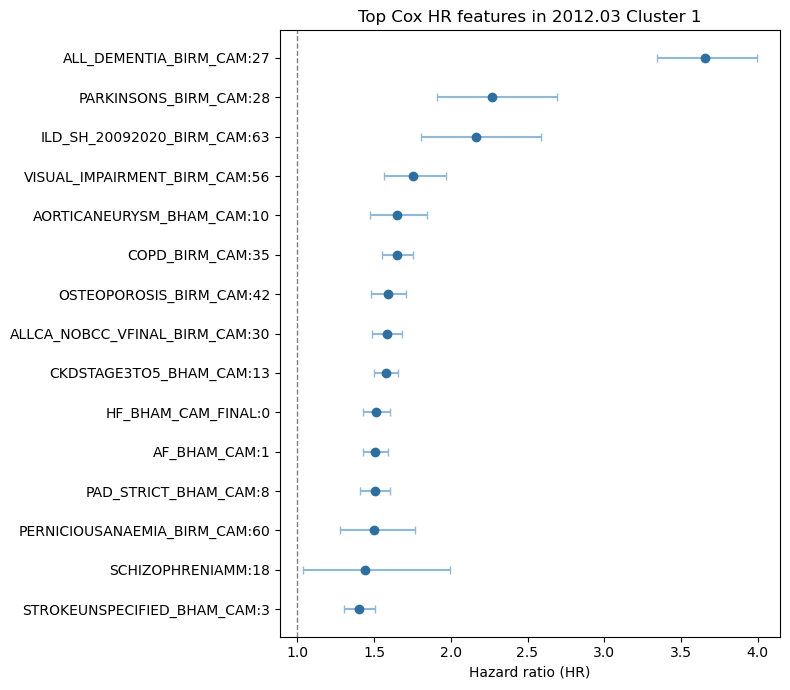

In [13]:
# Optional: simple forest plot for top high-risk features
# If matplotlib is not available in your environment, this cell can be skipped.

try:
    import matplotlib.pyplot as plt

    plot_df = high_hr_df.head(15).copy()
    plot_df = plot_df.sort_values("hr", ascending=True)

    fig, ax = plt.subplots(figsize=(8, 7))
    y = np.arange(len(plot_df))

    ax.errorbar(
        plot_df["hr"],
        y,
        xerr=[plot_df["hr"] - plot_df["ci_low"], plot_df["ci_high"] - plot_df["hr"]],
        fmt="o",
        color="#2f6f9f",
        ecolor="#8fb8d9",
        capsize=3,
    )
    ax.axvline(1, color="gray", linestyle="--", linewidth=1)
    ax.set_yticks(y)
    ax.set_yticklabels(plot_df["feature"])
    ax.set_xlabel("Hazard ratio (HR)")
    ax.set_title("Top Cox HR features in 2012.03 Cluster 1")
    fig.tight_layout()

    plot_file = output_dir / "cox_top_hr_forest_plot.png"
    fig.savefig(plot_file, dpi=300, bbox_inches="tight")
    print(f"Saved plot to: {plot_file}")
    plt.show()
except Exception as exc:
    print("Forest plot skipped:", exc)


In [14]:
# Quick interpretation table
# HR > 1 means higher death hazard; HR < 1 means lower death hazard in this univariate model.

interpretation_df = cox_result_df.head(12).copy()
interpretation_df["interpretation"] = np.where(
    interpretation_df["hr"] > 1,
    "higher death hazard",
    "lower death hazard",
)

interpretation_df[[
    "feature",
    "n_exposed",
    "n_exposed_event",
    "baseline_prevalence_percent",
    "hr",
    "ci_low",
    "ci_high",
    "p_value",
    "interpretation",
]]


,feature,n_exposed,n_exposed_event,baseline_prevalence_percent,hr,ci_low,ci_high,p_value,interpretation
0,ALL_DEMENTIA_BIRM_CAM:27,785,539,5.449118,3.654407,3.341209,3.996963,8.805273e-177,higher death hazard
1,CKDSTAGE3TO5_BHAM_CAM:13,5482,2911,38.053589,1.576249,1.500756,1.655539,8.496686e-74,higher death hazard
2,COPD_BIRM_CAM:35,2251,1328,15.625434,1.648707,1.552059,1.751373,3.495455e-59,higher death hazard
3,AF_BHAM_CAM:1,3663,1960,25.426905,1.505809,1.427932,1.587934,1.434431e-51,higher death hazard
4,ALLCA_NOBCC_VFINAL_BIRM_CAM:30,2297,1275,15.944745,1.583276,1.489109,1.683397,7.736037e-49,higher death hazard
5,HF_BHAM_CAM_FINAL:0,2990,1610,20.755241,1.514064,1.430997,1.601953,4.589486e-47,higher death hazard
6,PAD_STRICT_BHAM_CAM:8,1995,1123,13.848397,1.505266,1.411409,1.605366,1.390617e-35,higher death hazard
7,OSTEOPOROSIS_BIRM_CAM:42,1474,825,10.231848,1.590092,1.477939,1.710755,1.839609e-35,higher death hazard
8,ANY_DEAFNESS_HEARING_LOSS_BIRM_CAM_V2:66,3742,1916,25.975288,1.326399,1.257414,1.399169,3.554536e-25,higher death hazard
9,IHD_NOMI_BHAM_CAM:7,8543,3608,59.301680,0.775740,0.738564,0.814788,3.873763e-24,lower death hazard


In [15]:
# Build baseline 0/1 disease feature matrix for survival curve analysis
# A disease is counted as present at baseline if:
# B_MEDI is non-missing and BD_MEDI diagnosis date <= 2012-03-01.

baseline_feature_df = pd.DataFrame(index=cluster_df.index)

for b_col, bd_col, feature_name in disease_pairs:
    has_disease_code = cluster_df[b_col].notna().to_numpy()
    diagnosis_date = pd.to_datetime(cluster_df[bd_col], errors="coerce")
    baseline_feature_df[feature_name] = (
        has_disease_code
        & diagnosis_date.notna().to_numpy()
        & (diagnosis_date <= baseline_date).to_numpy()
    ).astype(int)

baseline_feature_df["baseline_disease_count"] = baseline_feature_df.sum(axis=1)

baseline_feature_file = output_dir / "baseline_disease_features_2012_cluster1.csv"
baseline_feature_file = safe_to_csv(baseline_feature_df, baseline_feature_file)

print(f"Saved baseline feature matrix to: {baseline_feature_file}")
baseline_feature_df.head()


Saved baseline feature matrix to: cox_survival_analysis_2012_cluster1_results/baseline_disease_features_2012_cluster1.csv


,HF_BHAM_CAM_FINAL:0,AF_BHAM_CAM:1,ISCHAEMICSTROKE_BHAM_CAM:2,STROKEUNSPECIFIED_BHAM_CAM:3,STROKE_HAEMRGIC_BHAM_CAM:4,HYPERTENSION_BHAM_CAM:5,MINFARCTION_BHAM_CAM:6,IHD_NOMI_BHAM_CAM:7,PAD_STRICT_BHAM_CAM:8,VALVULARDISEASES_BHAM_CAM:9,...,PTSDDIAGNOSIS_BIRM_CAM:64,PREVALENT_IBS_BIRM_CAM_V2:65,ANY_DEAFNESS_HEARING_LOSS_BIRM_CAM_V2:66,LEARNINGDISABILITY_BIRM_CAM_V2:67,ENDOMETRIOSIS_ADENOMYOSIS_BIRM_CAM_V2:68,POLYCYSTIC_OVARIAN_SYNDROME_PCOS_BIRM_CAM_V2:69,SICKLE_CELL_DISEASE_BIRM_CAM_V2:70,HAEMOCHROMATOSIS_BIRM_CAM_V2:71,FIBROMYALGIA_BHAM_CAM:72,baseline_disease_count
0,1,0,0,0,0,1,1,0,0,0,...,0,0,0,0,0,0,0,0,0,7
1,0,0,0,1,0,1,0,0,1,0,...,0,0,0,0,0,0,0,0,0,4
2,1,0,0,0,0,0,0,1,0,0,...,0,0,1,0,0,0,0,0,0,7
3,0,0,0,1,0,1,0,1,0,0,...,0,0,0,0,0,0,0,0,0,5
4,0,0,0,0,0,1,1,1,0,0,...,0,0,1,0,0,0,0,0,0,6


In [16]:
# Kaplan-Meier helper functions
# These functions compute survival probability without requiring lifelines.

KM_TIMEPOINT_YEARS = [1, 3, 5, 10]
KM_TIMEPOINT_DAYS = [int(y * 365.25) for y in KM_TIMEPOINT_YEARS]

def kaplan_meier_curve(time, event):
    time = np.asarray(time, dtype=float)
    event = np.asarray(event, dtype=bool)
    mask = np.isfinite(time) & (time > 0)
    time = time[mask]
    event = event[mask]

    event_times = np.unique(time[event])
    survival = 1.0
    rows = [{"time_days": 0.0, "survival": 1.0, "at_risk": len(time), "events": 0}]

    for t in event_times:
        at_risk = int(np.sum(time >= t))
        events_at_t = int(np.sum((time == t) & event))
        if at_risk <= 0:
            continue
        survival *= (1.0 - events_at_t / at_risk)
        rows.append({
            "time_days": float(t),
            "survival": float(survival),
            "at_risk": at_risk,
            "events": events_at_t,
        })

    curve_df = pd.DataFrame(rows)
    curve_df["time_years"] = curve_df["time_days"] / 365.25
    curve_df["cumulative_mortality"] = 1.0 - curve_df["survival"]
    return curve_df


def survival_at_times(curve_df, time_days_list):
    values = []
    times = curve_df["time_days"].to_numpy()
    surv = curve_df["survival"].to_numpy()
    for t in time_days_list:
        idx = np.searchsorted(times, t, side="right") - 1
        values.append(float(surv[idx]) if idx >= 0 else 1.0)
    return values


def disease_group_survival(feature_name, time=None, event_values=None):
    if time is None:
        time = duration_days.to_numpy()
    if event_values is None:
        event_values = event.to_numpy()

    x = baseline_feature_df[feature_name].to_numpy().astype(int)
    records = []
    curves = {}

    for group_value, group_label in [(1, "with_disease"), (0, "without_disease")]:
        mask = x == group_value
        curve_df = kaplan_meier_curve(time[mask], event_values[mask])
        curves[group_label] = curve_df
        surv_values = survival_at_times(curve_df, KM_TIMEPOINT_DAYS)

        row = {
            "feature": feature_name,
            "group": group_label,
            "n": int(mask.sum()),
            "n_events": int(event_values[mask].sum()),
        }
        for year, value in zip(KM_TIMEPOINT_YEARS, surv_values):
            row[f"survival_{year}y"] = value
            row[f"mortality_{year}y"] = 1 - value
        records.append(row)

    return pd.DataFrame(records), curves


In [17]:
# Calculate 1/3/5/10-year survival probabilities for every disease
# This creates the main table for comparing many diseases.

summary_records = []

for feature_name in baseline_feature_df.columns:
    if feature_name == "baseline_disease_count":
        continue

    group_df, _ = disease_group_survival(feature_name)
    if len(group_df) != 2:
        continue

    with_row = group_df[group_df["group"] == "with_disease"].iloc[0]
    without_row = group_df[group_df["group"] == "without_disease"].iloc[0]

    # Skip very rare diseases to avoid unstable survival estimates.
    if with_row["n"] < 20:
        continue

    row = {
        "feature": feature_name,
        "n_with_disease": int(with_row["n"]),
        "n_events_with_disease": int(with_row["n_events"]),
        "n_without_disease": int(without_row["n"]),
        "n_events_without_disease": int(without_row["n_events"]),
    }

    for year in KM_TIMEPOINT_YEARS:
        row[f"survival_{year}y_with"] = float(with_row[f"survival_{year}y"])
        row[f"survival_{year}y_without"] = float(without_row[f"survival_{year}y"])
        row[f"mortality_{year}y_with"] = float(with_row[f"mortality_{year}y"])
        row[f"mortality_{year}y_without"] = float(without_row[f"mortality_{year}y"])
        row[f"survival_difference_{year}y"] = row[f"survival_{year}y_with"] - row[f"survival_{year}y_without"]
        row[f"mortality_difference_{year}y"] = row[f"mortality_{year}y_with"] - row[f"mortality_{year}y_without"]

    summary_records.append(row)

survival_by_disease_df = pd.DataFrame(summary_records)
survival_by_disease_df = survival_by_disease_df.sort_values(
    "survival_difference_10y",
    ascending=True,
).reset_index(drop=True)

survival_summary_file = output_dir / "disease_group_survival_1_3_5_10_years.csv"
survival_summary_file = safe_to_csv(survival_by_disease_df, survival_summary_file)

print(f"Saved disease survival summary to: {survival_summary_file}")
survival_by_disease_df.head(20)


Saved disease survival summary to: cox_survival_analysis_2012_cluster1_results/disease_group_survival_1_3_5_10_years.csv


,feature,n_with_disease,n_events_with_disease,n_without_disease,n_events_without_disease,survival_1y_with,survival_1y_without,mortality_1y_with,mortality_1y_without,survival_difference_1y,...,mortality_5y_with,mortality_5y_without,survival_difference_5y,mortality_difference_5y,survival_10y_with,survival_10y_without,mortality_10y_with,mortality_10y_without,survival_difference_10y,mortality_difference_10y
0,ALL_DEMENTIA_BIRM_CAM:27,785,539,13621,5927,0.836685,0.943242,0.163315,0.056758,-0.106558,...,0.679878,0.265457,-0.414421,0.414421,0.053773,0.488868,0.946227,0.511132,-0.435095,0.435095
1,PARKINSONS_BIRM_CAM:28,211,135,14195,6331,0.831431,0.939207,0.168569,0.060793,-0.107776,...,0.516610,0.281673,-0.234937,0.234937,0.185827,0.473983,0.814173,0.526017,-0.288156,0.288156
2,ILD_SH_20092020_BIRM_CAM:63,169,122,14237,6344,0.875000,0.938386,0.125000,0.061614,-0.063386,...,0.533863,0.281831,-0.252032,0.252032,0.212904,0.473485,0.787096,0.526515,-0.260581,0.260581
3,AORTICANEURYSM_BHAM_CAM:10,532,324,13874,6142,0.908033,0.938762,0.091967,0.061238,-0.030729,...,0.371313,0.281647,-0.089666,0.089666,0.261348,0.477986,0.738652,0.522014,-0.216638,0.216638
4,COPD_BIRM_CAM:35,2251,1328,12155,5138,0.905692,0.943581,0.094308,0.056419,-0.037889,...,0.398537,0.263657,-0.134880,0.134880,0.319237,0.498590,0.680763,0.501410,-0.179353,0.179353
5,VISUAL_IMPAIRMENT_BIRM_CAM:56,533,303,13873,6163,0.872398,0.940100,0.127602,0.059900,-0.067703,...,0.450262,0.278814,-0.171448,0.171448,0.303904,0.476232,0.696096,0.523768,-0.172328,0.172328
6,CKDSTAGE3TO5_BHAM_CAM:13,5482,2911,8924,3555,0.917476,0.949969,0.082524,0.050031,-0.032493,...,0.359161,0.239584,-0.119576,0.119576,0.369486,0.530567,0.630514,0.469433,-0.161081,0.161081
7,OSTEOPOROSIS_BIRM_CAM:42,1474,825,12932,5641,0.893244,0.942662,0.106756,0.057338,-0.049418,...,0.399570,0.272116,-0.127455,0.127455,0.328079,0.485800,0.671921,0.514200,-0.157721,0.157721
8,PERNICIOUSANAEMIA_BIRM_CAM:60,278,150,14128,6316,0.901139,0.938346,0.098861,0.061654,-0.037207,...,0.376161,0.283181,-0.092980,0.092980,0.322193,0.472900,0.677807,0.527100,-0.150707,0.150707
9,ALLCA_NOBCC_VFINAL_BIRM_CAM:30,2297,1275,12109,5191,0.888667,0.946880,0.111333,0.053120,-0.058214,...,0.406563,0.262135,-0.144429,0.144429,0.345261,0.493407,0.654739,0.506593,-0.148146,0.148146


Saved plot to: cox_survival_analysis_2012_cluster1_results/km_and_mortality_ALL_DEMENTIA_BIRM_CAM_27.png


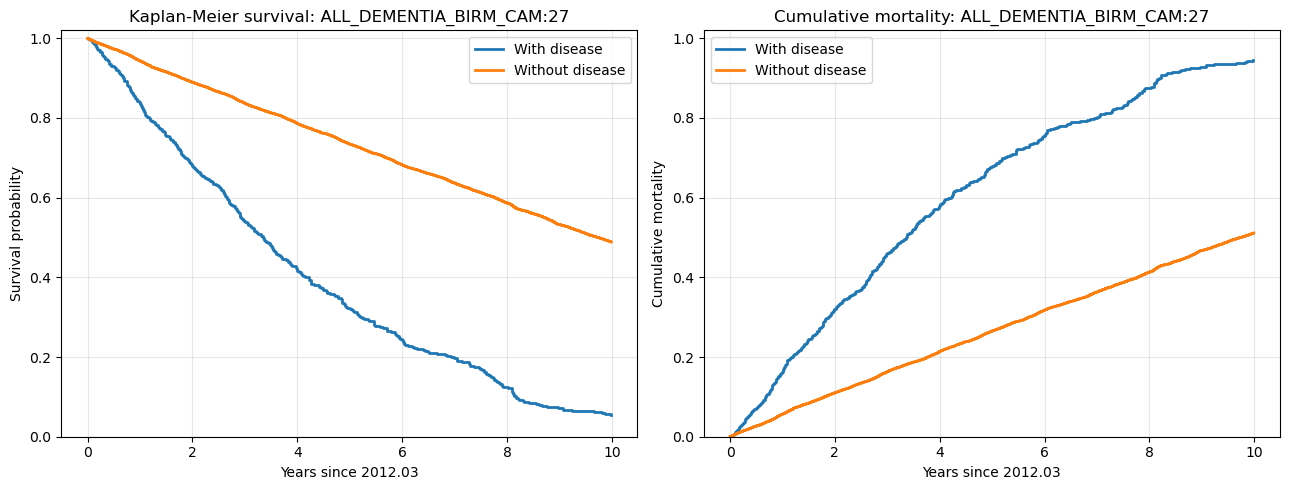

,feature,group,n,n_events,survival_1y,mortality_1y,survival_3y,mortality_3y,survival_5y,mortality_5y,survival_10y,mortality_10y
0,ALL_DEMENTIA_BIRM_CAM:27,with_disease,785,539,0.836685,0.163315,0.538764,0.461236,0.320122,0.679878,0.053773,0.946227
1,ALL_DEMENTIA_BIRM_CAM:27,without_disease,13621,5927,0.943242,0.056758,0.836765,0.163235,0.734543,0.265457,0.488868,0.511132


In [18]:
# Plot Kaplan-Meier survival curve and cumulative mortality curve for one disease
# Change selected_feature to any disease name in survival_by_disease_df["feature"].

selected_feature = survival_by_disease_df.iloc[0]["feature"]
# Example alternatives:
# selected_feature = "ALL_DEMENTIA_BIRM_CAM:27"
# selected_feature = "COPD_BIRM_CAM:35"
# selected_feature = "CKDSTAGE3TO5_BHAM_CAM:13"

try:
    import matplotlib.pyplot as plt

    group_df, curves = disease_group_survival(selected_feature)

    fig, axes = plt.subplots(1, 2, figsize=(13, 5))

    for group_label, curve_df in curves.items():
        label = "With disease" if group_label == "with_disease" else "Without disease"
        axes[0].step(
            curve_df["time_years"],
            curve_df["survival"],
            where="post",
            label=label,
            linewidth=2,
        )
        axes[1].step(
            curve_df["time_years"],
            curve_df["cumulative_mortality"],
            where="post",
            label=label,
            linewidth=2,
        )

    axes[0].set_title(f"Kaplan-Meier survival: {selected_feature}")
    axes[0].set_xlabel("Years since 2012.03")
    axes[0].set_ylabel("Survival probability")
    axes[0].set_ylim(0, 1.02)
    axes[0].legend()
    axes[0].grid(alpha=0.3)

    axes[1].set_title(f"Cumulative mortality: {selected_feature}")
    axes[1].set_xlabel("Years since 2012.03")
    axes[1].set_ylabel("Cumulative mortality")
    axes[1].set_ylim(0, 1.02)
    axes[1].legend()
    axes[1].grid(alpha=0.3)

    fig.tight_layout()
    plot_file = output_dir / f"km_and_mortality_{selected_feature.replace(':', '_').replace('/', '_')}.png"
    fig.savefig(plot_file, dpi=300, bbox_inches="tight")
    print(f"Saved plot to: {plot_file}")
    plt.show()

    display(group_df)
except Exception as exc:
    print("Plot skipped:", exc)
    group_df, curves = disease_group_survival(selected_feature)
    display(group_df)


Saved plot to: cox_survival_analysis_2012_cluster1_results/multi_disease_survival_curves.png


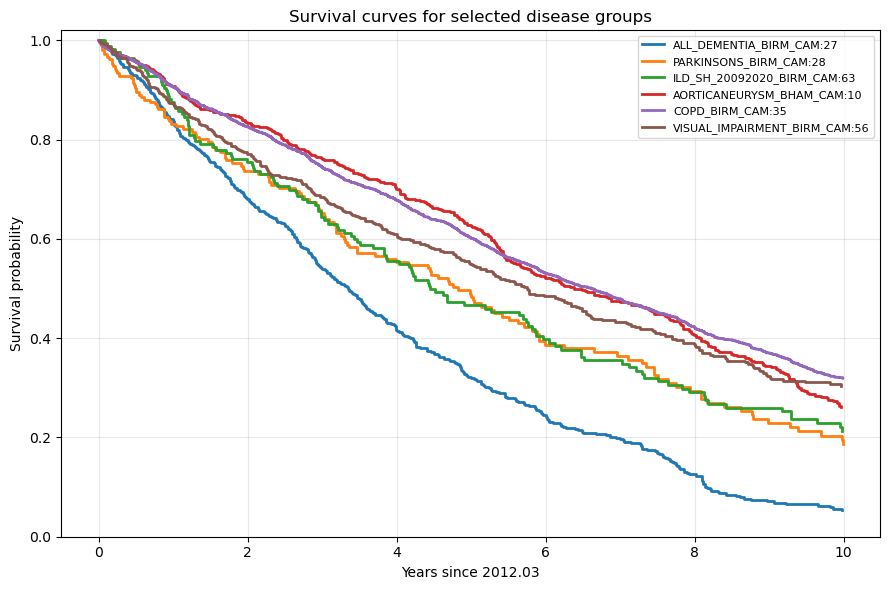

['ALL_DEMENTIA_BIRM_CAM:27',
 'PARKINSONS_BIRM_CAM:28',
 'ILD_SH_20092020_BIRM_CAM:63',
 'AORTICANEURYSM_BHAM_CAM:10',
 'COPD_BIRM_CAM:35',
 'VISUAL_IMPAIRMENT_BIRM_CAM:56']

In [19]:
# Multi-disease survival curve comparison
# This compares the WITH-disease group for several high-risk diseases.

selected_features = survival_by_disease_df.head(6)["feature"].tolist()
# You can manually overwrite it, for example:
# selected_features = ["ALL_DEMENTIA_BIRM_CAM:27", "COPD_BIRM_CAM:35", "CKDSTAGE3TO5_BHAM_CAM:13"]

try:
    import matplotlib.pyplot as plt

    fig, ax = plt.subplots(figsize=(9, 6))

    for feature_name in selected_features:
        _, curves = disease_group_survival(feature_name)
        curve_df = curves["with_disease"]
        ax.step(
            curve_df["time_years"],
            curve_df["survival"],
            where="post",
            linewidth=2,
            label=feature_name,
        )

    ax.set_title("Survival curves for selected disease groups")
    ax.set_xlabel("Years since 2012.03")
    ax.set_ylabel("Survival probability")
    ax.set_ylim(0, 1.02)
    ax.grid(alpha=0.3)
    ax.legend(fontsize=8)
    fig.tight_layout()

    plot_file = output_dir / "multi_disease_survival_curves.png"
    fig.savefig(plot_file, dpi=300, bbox_inches="tight")
    print(f"Saved plot to: {plot_file}")
    plt.show()
except Exception as exc:
    print("Plot skipped:", exc)

selected_features


Saved plot to: cox_survival_analysis_2012_cluster1_results/lowest_10y_survival_bar.png


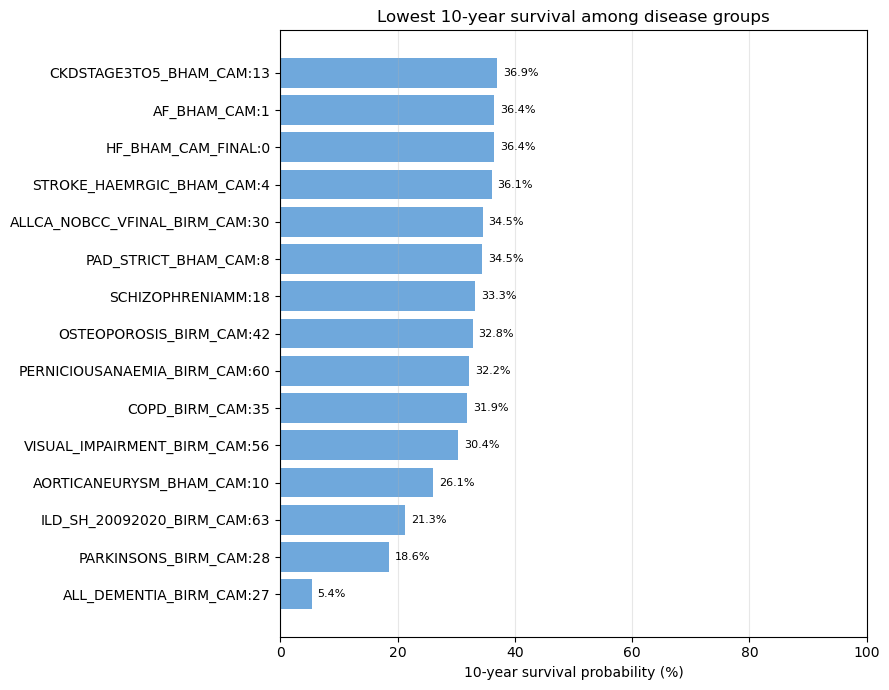

,feature,n_with_disease,survival_10y_with
0,ALL_DEMENTIA_BIRM_CAM:27,785,0.053773
1,PARKINSONS_BIRM_CAM:28,211,0.185827
2,ILD_SH_20092020_BIRM_CAM:63,169,0.212904
3,AORTICANEURYSM_BHAM_CAM:10,532,0.261348
5,VISUAL_IMPAIRMENT_BIRM_CAM:56,533,0.303904
4,COPD_BIRM_CAM:35,2251,0.319237
8,PERNICIOUSANAEMIA_BIRM_CAM:60,278,0.322193
7,OSTEOPOROSIS_BIRM_CAM:42,1474,0.328079
12,SCHIZOPHRENIAMM:18,65,0.332722
10,PAD_STRICT_BHAM_CAM:8,1995,0.344582


In [20]:
# Fixed-time survival bar chart
# Shows which diseases have the lowest 10-year survival probability.

top_n = 15
plot_year = 10
plot_col = f"survival_{plot_year}y_with"

fixed_time_plot_df = survival_by_disease_df.sort_values(plot_col, ascending=True).head(top_n).copy()

try:
    import matplotlib.pyplot as plt

    fig, ax = plt.subplots(figsize=(9, 7))
    plot_df = fixed_time_plot_df.sort_values(plot_col, ascending=True)

    ax.barh(plot_df["feature"], plot_df[plot_col] * 100, color="#6fa8dc")
    ax.set_xlabel(f"{plot_year}-year survival probability (%)")
    ax.set_title(f"Lowest {plot_year}-year survival among disease groups")
    ax.set_xlim(0, 100)
    ax.grid(axis="x", alpha=0.3)

    for i, value in enumerate(plot_df[plot_col] * 100):
        ax.text(value + 1, i, f"{value:.1f}%", va="center", fontsize=8)

    fig.tight_layout()
    plot_file = output_dir / f"lowest_{plot_year}y_survival_bar.png"
    fig.savefig(plot_file, dpi=300, bbox_inches="tight")
    print(f"Saved plot to: {plot_file}")
    plt.show()
except Exception as exc:
    print("Plot skipped:", exc)

fixed_time_plot_df[["feature", "n_with_disease", plot_col]].head(top_n)


Saved plot to: cox_survival_analysis_2012_cluster1_results/largest_10y_survival_difference_bar.png


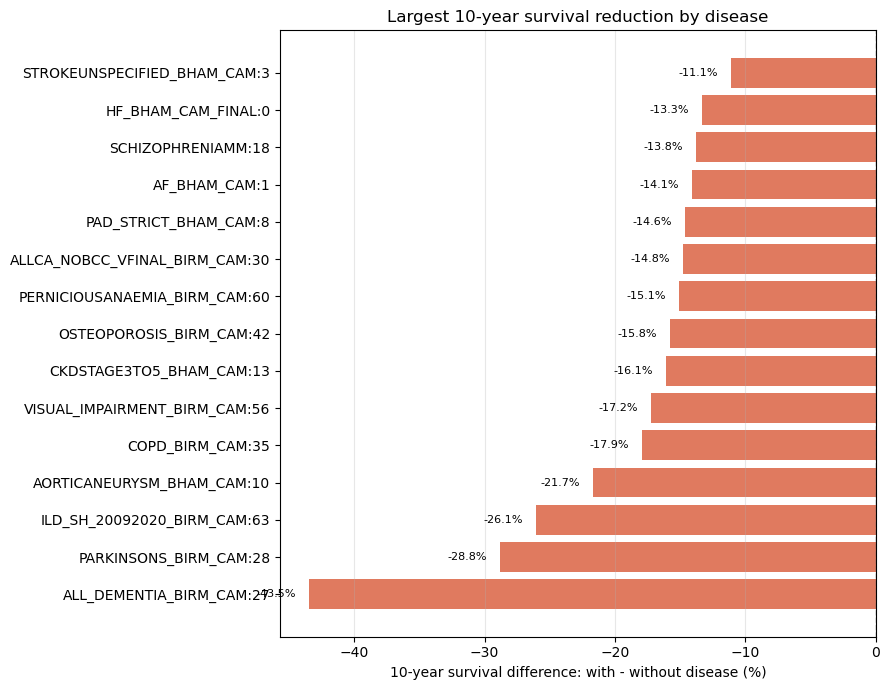

,feature,n_with_disease,survival_10y_with,survival_10y_without,survival_difference_10y
0,ALL_DEMENTIA_BIRM_CAM:27,785,0.053773,0.488868,-0.435095
1,PARKINSONS_BIRM_CAM:28,211,0.185827,0.473983,-0.288156
2,ILD_SH_20092020_BIRM_CAM:63,169,0.212904,0.473485,-0.260581
3,AORTICANEURYSM_BHAM_CAM:10,532,0.261348,0.477986,-0.216638
4,COPD_BIRM_CAM:35,2251,0.319237,0.498590,-0.179353
5,VISUAL_IMPAIRMENT_BIRM_CAM:56,533,0.303904,0.476232,-0.172328
6,CKDSTAGE3TO5_BHAM_CAM:13,5482,0.369486,0.530567,-0.161081
7,OSTEOPOROSIS_BIRM_CAM:42,1474,0.328079,0.485800,-0.157721
8,PERNICIOUSANAEMIA_BIRM_CAM:60,278,0.322193,0.472900,-0.150707
9,ALLCA_NOBCC_VFINAL_BIRM_CAM:30,2297,0.345261,0.493407,-0.148146


In [21]:
# Survival difference bar chart
# Difference = survival_with_disease - survival_without_disease.
# More negative values mean the disease group has lower survival than the non-disease group.

top_n = 15
plot_year = 10
diff_col = f"survival_difference_{plot_year}y"

survival_diff_plot_df = survival_by_disease_df.sort_values(diff_col, ascending=True).head(top_n).copy()

try:
    import matplotlib.pyplot as plt

    fig, ax = plt.subplots(figsize=(9, 7))
    plot_df = survival_diff_plot_df.sort_values(diff_col, ascending=True)

    ax.barh(plot_df["feature"], plot_df[diff_col] * 100, color="#e07a5f")
    ax.axvline(0, color="gray", linestyle="--", linewidth=1)
    ax.set_xlabel(f"{plot_year}-year survival difference: with - without disease (%)")
    ax.set_title(f"Largest {plot_year}-year survival reduction by disease")
    ax.grid(axis="x", alpha=0.3)

    for i, value in enumerate(plot_df[diff_col] * 100):
        ax.text(value - 1, i, f"{value:.1f}%", va="center", ha="right", fontsize=8)

    fig.tight_layout()
    plot_file = output_dir / f"largest_{plot_year}y_survival_difference_bar.png"
    fig.savefig(plot_file, dpi=300, bbox_inches="tight")
    print(f"Saved plot to: {plot_file}")
    plt.show()
except Exception as exc:
    print("Plot skipped:", exc)

survival_diff_plot_df[[
    "feature",
    "n_with_disease",
    f"survival_{plot_year}y_with",
    f"survival_{plot_year}y_without",
    diff_col,
]].head(top_n)


In [22]:
# Final compact ranking table for reporting
# This table is often the easiest one to explain in slides.

report_cols = [
    "feature",
    "n_with_disease",
    "n_events_with_disease",
    "survival_1y_with",
    "survival_3y_with",
    "survival_5y_with",
    "survival_10y_with",
    "survival_10y_without",
    "survival_difference_10y",
    "mortality_10y_with",
    "mortality_10y_without",
    "mortality_difference_10y",
]

survival_report_df = survival_by_disease_df[report_cols].copy()

percent_cols = [c for c in survival_report_df.columns if c.startswith("survival_") or c.startswith("mortality_")]
for col in percent_cols:
    survival_report_df[col] = survival_report_df[col] * 100

report_file = output_dir / "disease_survival_report_percent.csv"
report_file = safe_to_csv(survival_report_df, report_file)

print(f"Saved reporting table to: {report_file}")
survival_report_df.head(20)


Saved reporting table to: cox_survival_analysis_2012_cluster1_results/disease_survival_report_percent.csv


,feature,n_with_disease,n_events_with_disease,survival_1y_with,survival_3y_with,survival_5y_with,survival_10y_with,survival_10y_without,survival_difference_10y,mortality_10y_with,mortality_10y_without,mortality_difference_10y
0,ALL_DEMENTIA_BIRM_CAM:27,785,539,83.668462,53.876383,32.012196,5.377298,48.886758,-43.509460,94.622702,51.113242,43.509460
1,PARKINSONS_BIRM_CAM:28,211,135,83.143070,65.170414,48.338996,18.582664,47.398298,-28.815634,81.417336,52.601702,28.815634
2,ILD_SH_20092020_BIRM_CAM:63,169,122,87.500000,64.325366,46.613666,21.290413,47.348475,-26.058062,78.709587,52.651525,26.058062
3,AORTICANEURYSM_BHAM_CAM:10,532,324,90.803306,76.295894,62.868730,26.134836,47.798637,-21.663801,73.865164,52.201363,21.663801
4,COPD_BIRM_CAM:35,2251,1328,90.569184,74.414957,60.146293,31.923661,49.858998,-17.935336,68.076339,50.141002,17.935336
5,VISUAL_IMPAIRMENT_BIRM_CAM:56,533,303,87.239786,68.522697,54.973775,30.390424,47.623222,-17.232799,69.609576,52.376778,17.232799
6,CKDSTAGE3TO5_BHAM_CAM:13,5482,2911,91.747604,77.499430,64.083948,36.948619,53.056741,-16.108122,63.051381,46.943259,16.108122
7,OSTEOPOROSIS_BIRM_CAM:42,1474,825,89.324401,73.389937,60.042962,32.807895,48.580039,-15.772144,67.192105,51.419961,15.772144
8,PERNICIOUSANAEMIA_BIRM_CAM:60,278,150,90.113893,75.452799,62.383908,32.219301,47.289998,-15.070698,67.780699,52.710002,15.070698
9,ALLCA_NOBCC_VFINAL_BIRM_CAM:30,2297,1275,88.866663,72.678990,59.343660,34.526109,49.340703,-14.814595,65.473891,50.659297,14.814595


In [23]:
# Section 3. Build age and sex covariates for adjusted Cox models
# age_2012 uses YEAR_OF_BIRTH. Sex is dummy-coded; the most common sex is used as reference.

adjusted_covariate_df = pd.DataFrame(index=cluster_df.index)

year_of_birth_parsed = pd.to_datetime(cluster_df["YEAR_OF_BIRTH"], errors="coerce")
year_of_birth_numeric = pd.to_numeric(cluster_df["YEAR_OF_BIRTH"], errors="coerce")
year_of_birth = year_of_birth_parsed.dt.year.fillna(year_of_birth_numeric)

adjusted_covariate_df["age_2012"] = 2012 - year_of_birth

sex_raw = cluster_df["SEX"].astype("string").str.strip().fillna("Unknown")
sex_counts = sex_raw.value_counts(dropna=False)
sex_reference = sex_counts.index[0]
print("Sex reference group:", sex_reference)
print(sex_counts)

for sex_value in sex_counts.index[1:]:
    safe_name = str(sex_value).replace(" ", "_").replace("/", "_")
    adjusted_covariate_df[f"sex_{safe_name}"] = (sex_raw == sex_value).astype(int)

# Keep only rows with valid age and survival time.
adjusted_model_mask = adjusted_covariate_df["age_2012"].notna() & duration_days.notna() & (duration_days > 0)

print("Rows available for adjusted models:", int(adjusted_model_mask.sum()))
adjusted_covariate_df.head()


Sex reference group: M
SEX
M    7803
F    6603
Name: count, dtype: Int64
Rows available for adjusted models: 14406


,age_2012,sex_F
0,73,1
1,58,0
2,65,1
3,63,0
4,76,0


In [24]:
# Generic multivariable Cox regression helper
# This supports disease + age + sex, and multiple diseases + age + sex.

def fit_cox_model(time, event, X, feature_names, max_iter=60, tol=1e-7, ridge=1e-6):
    time = np.asarray(time, dtype=float)
    event = np.asarray(event, dtype=bool)
    X = np.asarray(X, dtype=float)

    mask = np.isfinite(time) & (time > 0) & np.isfinite(X).all(axis=1)
    time = time[mask]
    event = event[mask]
    X = X[mask]

    n, p = X.shape
    n_event = int(event.sum())
    if n <= p + 5 or n_event <= p + 5:
        return None

    # Standardize continuous-like variables for numeric stability, but keep 0/1 variables unchanged.
    X_work = X.copy()
    scale_info = []
    for j in range(p):
        values = X_work[:, j]
        unique_values = np.unique(values[~np.isnan(values)])
        is_binary = len(unique_values) <= 2 and set(unique_values).issubset({0.0, 1.0})
        if is_binary:
            scale_info.append((0.0, 1.0, True))
        else:
            mean = values.mean()
            sd = values.std(ddof=0)
            if sd <= 0:
                sd = 1.0
            X_work[:, j] = (values - mean) / sd
            scale_info.append((mean, sd, False))

    order = np.argsort(time)
    time = time[order]
    event = event[order]
    X_work = X_work[order]
    event_times = np.unique(time[event])

    beta = np.zeros(p, dtype=float)
    hessian = None

    for _ in range(max_iter):
        eta = np.clip(X_work @ beta, -50, 50)
        exp_eta = np.exp(eta)
        grad = np.zeros(p, dtype=float)
        info = np.zeros((p, p), dtype=float)

        for t in event_times:
            event_mask = (time == t) & event
            risk_mask = time >= t
            d = int(event_mask.sum())
            if d == 0:
                continue

            X_risk = X_work[risk_mask]
            w = exp_eta[risk_mask]
            s0 = w.sum()
            if s0 <= 0:
                continue
            s1 = (X_risk * w[:, None]).sum(axis=0)
            weighted_x = X_risk * w[:, None]
            s2 = weighted_x.T @ X_risk

            mean_x = s1 / s0
            grad += X_work[event_mask].sum(axis=0) - d * mean_x
            info += d * (s2 / s0 - np.outer(mean_x, mean_x))

        info_ridge = info + np.eye(p) * ridge
        try:
            step = np.linalg.solve(info_ridge, grad)
        except np.linalg.LinAlgError:
            step = np.linalg.pinv(info_ridge) @ grad
        beta += step
        hessian = info
        if np.max(np.abs(step)) < tol:
            break

    info_ridge = hessian + np.eye(p) * ridge
    try:
        cov_scaled = np.linalg.inv(info_ridge)
    except np.linalg.LinAlgError:
        cov_scaled = np.linalg.pinv(info_ridge)

    rows = []
    for j, name in enumerate(feature_names):
        mean, sd, is_binary = scale_info[j]
        if is_binary:
            coef = beta[j]
            se = math.sqrt(max(cov_scaled[j, j], 0))
        else:
            coef = beta[j] / sd
            se = math.sqrt(max(cov_scaled[j, j], 0)) / sd

        z = coef / se if se > 0 else np.nan
        p_value = _normal_two_sided_p(z) if np.isfinite(z) else np.nan
        rows.append({
            "feature": name,
            "coef": coef,
            "hr": math.exp(coef),
            "ci_low": math.exp(coef - 1.96 * se),
            "ci_high": math.exp(coef + 1.96 * se),
            "p_value": p_value,
            "se": se,
            "n": n,
            "n_event": n_event,
        })

    result_df = pd.DataFrame(rows)
    return result_df


In [25]:
# Efficient C-index, bootstrap CI, and train/test helpers
# C-index evaluates discrimination: whether a participant with a higher predicted
# risk tends to experience death earlier. A value of 0.50 is random ranking.
#
# This implementation is O(n log n), which is much faster than pairwise O(n^2)
# evaluation for the ~14,000-person cohort in this notebook.

class _FenwickTree:
    """Frequency tree used to calculate Harrell's C-index efficiently."""

    def __init__(self, size):
        self.size = int(size)
        self.tree = np.zeros(self.size + 1, dtype=np.int64)

    def add(self, index, value):
        index = int(index)
        while index <= self.size:
            self.tree[index] += value
            index += index & -index

    def prefix_sum(self, index):
        index = int(index)
        total = 0
        while index > 0:
            total += self.tree[index]
            index -= index & -index
        return total


def concordance_index_censored(time, event, risk_score):
    """
    Harrell's C-index for right-censored survival data.

    Higher risk_score must mean higher predicted hazard / earlier death.
    Censored observations are used only when they were still under observation
    after an observed death, which is the standard comparable-pair logic.
    """
    time = np.asarray(time, dtype=float)
    event = np.asarray(event, dtype=bool)
    risk_score = np.asarray(risk_score, dtype=float)

    mask = np.isfinite(time) & np.isfinite(risk_score) & (time > 0)
    time = time[mask]
    event = event[mask]
    risk_score = risk_score[mask]

    if len(time) < 2 or int(event.sum()) == 0:
        return np.nan

    # Process from the latest observed time to the earliest. At each event time,
    # the tree contains only people observed strictly later, i.e. valid comparators.
    order = np.argsort(-time, kind="mergesort")
    time = time[order]
    event = event[order]
    risk_score = risk_score[order]

    unique_scores = np.unique(risk_score)
    risk_rank = np.searchsorted(unique_scores, risk_score, side="left") + 1
    tree = _FenwickTree(len(unique_scores))

    concordant = 0.0
    tied_risk = 0.0
    comparable = 0
    n_later = 0

    i = 0
    n = len(time)
    while i < n:
        j = i + 1
        while j < n and time[j] == time[i]:
            j += 1

        # Score all events at this exact time before adding the time group.
        # This correctly excludes tied follow-up times from comparison.
        for k in range(i, j):
            if event[k]:
                rank = int(risk_rank[k])
                n_lower_risk = tree.prefix_sum(rank - 1)
                n_equal_risk = tree.prefix_sum(rank) - n_lower_risk

                concordant += n_lower_risk
                tied_risk += n_equal_risk
                comparable += n_later

        # People at this time become comparators only for earlier events.
        for k in range(i, j):
            tree.add(risk_rank[k], 1)
            n_later += 1

        i = j

    if comparable == 0:
        return np.nan

    return (concordant + 0.5 * tied_risk) / comparable


def bootstrap_cindex_comparison(
    time,
    event,
    risk_score_map,
    reference_model,
    n_bootstrap=200,
    seed=2026,
):
    """
    Obtain bootstrap 95% CIs for test-set C-index and paired differences
    versus a reference model. All candidate models use the same resampled
    participants in each bootstrap repetition.

    For final reporting, increase n_bootstrap to 1000 if runtime permits.
    """
    time = np.asarray(time, dtype=float)
    event = np.asarray(event, dtype=bool)
    risk_score_map = {
        name: np.asarray(scores, dtype=float)
        for name, scores in risk_score_map.items()
    }

    if reference_model not in risk_score_map:
        raise ValueError(f"Reference model '{reference_model}' is not available.")

    n = len(time)
    if n == 0:
        raise ValueError("No test observations available for bootstrap C-index.")

    point_estimates = {
        name: concordance_index_censored(time, event, scores)
        for name, scores in risk_score_map.items()
    }

    rng = np.random.default_rng(seed)
    bootstrap_cindex = {name: [] for name in risk_score_map}
    bootstrap_delta = {name: [] for name in risk_score_map}

    for _ in range(int(n_bootstrap)):
        idx = rng.integers(0, n, size=n)

        cindex_this_draw = {}
        for name, scores in risk_score_map.items():
            c_value = concordance_index_censored(time[idx], event[idx], scores[idx])
            if np.isfinite(c_value):
                cindex_this_draw[name] = c_value
                bootstrap_cindex[name].append(c_value)

        if reference_model in cindex_this_draw:
            reference_value = cindex_this_draw[reference_model]
            for name, c_value in cindex_this_draw.items():
                bootstrap_delta[name].append(c_value - reference_value)

    records = []
    for name in risk_score_map:
        c_values = np.asarray(bootstrap_cindex[name], dtype=float)
        delta_values = np.asarray(bootstrap_delta[name], dtype=float)

        record = {
            "model_key": name,
            "test_c_index": point_estimates[name],
            "test_c_index_ci_low": np.nan,
            "test_c_index_ci_high": np.nan,
            "delta_c_index_vs_reference": point_estimates[name] - point_estimates[reference_model],
            "delta_ci_low": np.nan,
            "delta_ci_high": np.nan,
            "bootstrap_repetitions_valid": int(len(c_values)),
        }

        if len(c_values) >= 20:
            record["test_c_index_ci_low"] = float(np.quantile(c_values, 0.025))
            record["test_c_index_ci_high"] = float(np.quantile(c_values, 0.975))

        if len(delta_values) >= 20:
            record["delta_ci_low"] = float(np.quantile(delta_values, 0.025))
            record["delta_ci_high"] = float(np.quantile(delta_values, 0.975))

        records.append(record)

    return pd.DataFrame(records)


def make_train_test_mask(base_mask, event_values, test_size=0.30, seed=42):
    """Stratified train/test split by death-event status."""
    rng = np.random.default_rng(seed)
    base_mask = np.asarray(base_mask, dtype=bool)
    event_values = np.asarray(event_values, dtype=bool)

    eligible_idx = np.where(base_mask)[0]
    event_idx = eligible_idx[event_values[eligible_idx]]
    censored_idx = eligible_idx[~event_values[eligible_idx]]

    rng.shuffle(event_idx)
    rng.shuffle(censored_idx)

    n_event_test = max(1, int(round(len(event_idx) * test_size)))
    n_censored_test = max(1, int(round(len(censored_idx) * test_size)))

    test_idx = np.concatenate([event_idx[:n_event_test], censored_idx[:n_censored_test]])
    train_idx = np.concatenate([event_idx[n_event_test:], censored_idx[n_censored_test:]])

    train_mask = np.zeros(len(base_mask), dtype=bool)
    test_mask = np.zeros(len(base_mask), dtype=bool)
    train_mask[train_idx] = True
    test_mask[test_idx] = True

    return train_mask, test_mask


In [26]:

def make_stratified_kfold_masks(base_mask, event_values, n_splits=5, n_repeats=5, seed=42):
    """
    Returns a list of dicts: {"rep":.., "fold":.., "train_mask":.., "test_mask":..}.
    n_splits controls the per-fold train/test ratio (5 -> 80/20).
    n_repeats reruns the whole k-fold with new shuffles.
    """
    base_mask = np.asarray(base_mask, dtype=bool)
    event_values = np.asarray(event_values, dtype=bool)
    eligible_idx = np.where(base_mask)[0]

    splits = []
    for rep in range(n_repeats):
        rng = np.random.default_rng(seed + rep)
        event_idx = eligible_idx[event_values[eligible_idx]].copy()
        censored_idx = eligible_idx[~event_values[eligible_idx]].copy()
        rng.shuffle(event_idx)
        rng.shuffle(censored_idx)

        event_folds = np.array_split(event_idx, n_splits)
        censored_folds = np.array_split(censored_idx, n_splits)

        for fold in range(n_splits):
            test_idx = np.concatenate([event_folds[fold], censored_folds[fold]])
            train_idx = np.concatenate(
                [event_folds[i] for i in range(n_splits) if i != fold]
                + [censored_folds[i] for i in range(n_splits) if i != fold]
            )
            train_mask = np.zeros(len(base_mask), dtype=bool)
            test_mask = np.zeros(len(base_mask), dtype=bool)
            train_mask[train_idx] = True
            test_mask[test_idx] = True
            splits.append({"rep": rep, "fold": fold, "train_mask": train_mask, "test_mask": test_mask})
    return splits

In [27]:
# Section 4. Single disease + age + sex adjusted Cox models
# Each model: survival time ~ one disease + age_2012 + sex dummies.

adjusted_records = []
base_covariate_cols = adjusted_covariate_df.columns.tolist()

time = duration_days.to_numpy()
event_np = event.to_numpy()

for feature_name in baseline_feature_df.columns:
    if feature_name == "baseline_disease_count":
        continue

    x_disease = baseline_feature_df[feature_name].to_numpy().astype(float)
    n_exposed = int(x_disease[adjusted_model_mask.to_numpy()].sum())
    if n_exposed < 20:
        continue

    X_model_df = pd.concat(
        [
            pd.Series(x_disease, name=feature_name, index=cluster_df.index),
            adjusted_covariate_df,
        ],
        axis=1,
    )

    model_df = fit_cox_model(
        time=time,
        event=event_np,
        X=X_model_df.to_numpy(),
        feature_names=X_model_df.columns.tolist(),
    )
    if model_df is None:
        continue

    disease_row = model_df[model_df["feature"] == feature_name].iloc[0].to_dict()
    disease_row["n_exposed"] = n_exposed
    disease_row["n_exposed_event"] = int(event_np[(x_disease == 1) & adjusted_model_mask.to_numpy()].sum())
    disease_row["baseline_prevalence_percent"] = n_exposed / int(adjusted_model_mask.sum()) * 100
    adjusted_records.append(disease_row)

age_sex_adjusted_cox_df = pd.DataFrame(adjusted_records)

if age_sex_adjusted_cox_df.empty:
    raise ValueError(
        "No age-sex adjusted Cox models were fitted. "
        "Check age_2012, sex covariates, baseline disease features, and duration/event variables."
    )

age_sex_adjusted_cox_df = age_sex_adjusted_cox_df[[
    "feature",
    "n",
    "n_event",
    "n_exposed",
    "n_exposed_event",
    "baseline_prevalence_percent",
    "hr",
    "ci_low",
    "ci_high",
    "p_value",
    "coef",
    "se",
]]
age_sex_adjusted_cox_df = age_sex_adjusted_cox_df.sort_values(
    ["p_value", "hr"],
    ascending=[True, False],
).reset_index(drop=True)

adjusted_file = output_dir / "cox_age_sex_adjusted_single_disease.csv"
adjusted_file = safe_to_csv(age_sex_adjusted_cox_df, adjusted_file)

print(f"Saved age-sex adjusted single-disease Cox results to: {adjusted_file}")
age_sex_adjusted_cox_df.head(20)


Saved age-sex adjusted single-disease Cox results to: cox_survival_analysis_2012_cluster1_results/cox_age_sex_adjusted_single_disease.csv


,feature,n,n_event,n_exposed,n_exposed_event,baseline_prevalence_percent,hr,ci_low,ci_high,p_value,coef,se
0,COPD_BIRM_CAM:35,14406,6466,2251,1328,15.625434,1.667595,1.569726,1.771566,1.106486e-61,0.511383,0.030858
1,ALL_DEMENTIA_BIRM_CAM:27,14406,6466,785,539,5.449118,2.143583,1.956762,2.348241,2.300426e-60,0.762479,0.046524
2,PAD_STRICT_BHAM_CAM:8,14406,6466,1995,1123,13.848397,1.516662,1.421909,1.617729,1.056318e-36,0.416512,0.032914
3,HF_BHAM_CAM_FINAL:0,14406,6466,2990,1610,20.755241,1.413769,1.335939,1.496134,4.245536e-33,0.346259,0.028890
4,ILD_SH_20092020_BIRM_CAM:63,14406,6466,169,122,1.173122,2.405359,2.010296,2.878060,8.962475e-22,0.877699,0.091539
5,ALCOHOLMISUSE_BIRM_CAM:20,14406,6466,504,241,3.498542,1.831350,1.607342,2.086578,9.962936e-20,0.605054,0.066567
6,AF_BHAM_CAM:1,14406,6466,3663,1960,25.426905,1.232078,1.168016,1.299653,1.846684e-14,0.208702,0.027243
7,TYPE2DIABETES_11_3_21_BIRM_CAM:12,14406,6466,4524,2109,31.403582,1.225730,1.163123,1.291707,2.759238e-14,0.203537,0.026749
8,ASTHMA_PUSHASTHMA:34,14406,6466,2940,1447,20.408163,1.240107,1.169345,1.315151,7.027183e-13,0.215198,0.029976
9,ALLCA_NOBCC_VFINAL_BIRM_CAM:30,14406,6466,2297,1275,15.944745,1.250416,1.175669,1.329916,1.193775e-12,0.223477,0.031449


In [28]:
# Compare univariate Cox vs age-sex adjusted Cox
# This shows how much age and sex explain the original disease HR.

cox_comparison_df = cox_result_df[[
    "feature", "hr", "ci_low", "ci_high", "p_value"
]].rename(columns={
    "hr": "univariate_hr",
    "ci_low": "univariate_ci_low",
    "ci_high": "univariate_ci_high",
    "p_value": "univariate_p_value",
})

cox_comparison_df = cox_comparison_df.merge(
    age_sex_adjusted_cox_df[["feature", "hr", "ci_low", "ci_high", "p_value"]].rename(columns={
        "hr": "age_sex_adjusted_hr",
        "ci_low": "age_sex_adjusted_ci_low",
        "ci_high": "age_sex_adjusted_ci_high",
        "p_value": "age_sex_adjusted_p_value",
    }),
    on="feature",
    how="left",
)

cox_comparison_df["hr_change_after_age_sex_adjustment"] = (
    cox_comparison_df["age_sex_adjusted_hr"] - cox_comparison_df["univariate_hr"]
)

comparison_file = output_dir / "cox_univariate_vs_age_sex_adjusted_comparison.csv"
comparison_file = safe_to_csv(cox_comparison_df, comparison_file)

print(f"Saved comparison table to: {comparison_file}")
cox_comparison_df.head(20)


Saved comparison table to: cox_survival_analysis_2012_cluster1_results/cox_univariate_vs_age_sex_adjusted_comparison.csv


,feature,univariate_hr,univariate_ci_low,univariate_ci_high,univariate_p_value,age_sex_adjusted_hr,age_sex_adjusted_ci_low,age_sex_adjusted_ci_high,age_sex_adjusted_p_value,hr_change_after_age_sex_adjustment
0,ALL_DEMENTIA_BIRM_CAM:27,3.654407,3.341209,3.996963,8.805273e-177,2.143583,1.956762,2.348241,2.300426e-60,-1.510824
1,CKDSTAGE3TO5_BHAM_CAM:13,1.576249,1.500756,1.655539,8.496686e-74,1.129330,1.073706,1.187835,2.361471e-06,-0.446919
2,COPD_BIRM_CAM:35,1.648707,1.552059,1.751373,3.495455e-59,1.667595,1.569726,1.771566,1.106486e-61,0.018889
3,AF_BHAM_CAM:1,1.505809,1.427932,1.587934,1.434431e-51,1.232078,1.168016,1.299653,1.846684e-14,-0.273731
4,ALLCA_NOBCC_VFINAL_BIRM_CAM:30,1.583276,1.489109,1.683397,7.736037e-49,1.250416,1.175669,1.329916,1.193775e-12,-0.332859
5,HF_BHAM_CAM_FINAL:0,1.514064,1.430997,1.601953,4.589486e-47,1.413769,1.335939,1.496134,4.245536e-33,-0.100294
6,PAD_STRICT_BHAM_CAM:8,1.505266,1.411409,1.605366,1.390617e-35,1.516662,1.421909,1.617729,1.056318e-36,0.011395
7,OSTEOPOROSIS_BIRM_CAM:42,1.590092,1.477939,1.710755,1.839609e-35,1.260582,1.167380,1.361225,3.440685e-09,-0.329510
8,ANY_DEAFNESS_HEARING_LOSS_BIRM_CAM_V2:66,1.326399,1.257414,1.399169,3.554536e-25,0.983652,0.931722,1.038477,5.514144e-01,-0.342747
9,IHD_NOMI_BHAM_CAM:7,0.775740,0.738564,0.814788,3.873763e-24,0.858797,0.816991,0.902743,2.252963e-09,0.083057


In [29]:
# Section 5. Compare Cox models using held-out C-index
# Every disease that passes training-set screening is included as a
# candidate, and models are built by adding candidates ONE AT A TIME
# (1, 2, 3, ..., all candidates), so we get a full curve of how test
# C-index changes as more diseases are added -- not just a few sparse
# checkpoints like top-5/10/15.
#
# Core principle (unchanged from before):
# - The train/test split is created once and shared by every model.
# - Disease screening and coefficient fitting occur on the training set only.
# - Model ranking uses the held-out TEST C-index, not the training C-index.
# - Bootstrap CIs quantify uncertainty and paired ΔC-index compares every
#   expanded model with the age + sex reference model.

min_exposed_for_multivariable = 50
min_exposed_event_for_multivariable = 10
test_size_for_cox = 0.20
cox_split_seed = 42

# 200 gives stable exploratory intervals with reasonable runtime. Set to 1000
# for a final report/manuscript if runtime is acceptable.
n_bootstrap_cindex = 200
cindex_bootstrap_seed = 2026

full_model_mask_np = (
    adjusted_model_mask.to_numpy()
    & np.isfinite(baseline_feature_df.to_numpy()).all(axis=1)
)
train_mask_np, test_mask_np = make_train_test_mask(
    base_mask=full_model_mask_np,
    event_values=event.to_numpy(),
    test_size=test_size_for_cox,
    seed=cox_split_seed,
)

time_all = duration_days.to_numpy()
event_all = event.to_numpy()
section5_train_mask_np = train_mask_np.copy()   

print("Cox train/test split")
print("Train rows:", int(train_mask_np.sum()), "Train deaths:", int(event_all[train_mask_np].sum()))
print("Test rows:", int(test_mask_np.sum()), "Test deaths:", int(event_all[test_mask_np].sum()))

# -------------------------------------------------------------------------
# 1. Select candidate diseases on TRAINING data only.
#    Each screening model: survival ~ one disease + age + sex.
#    NOTE: no top-N cutoff here. Every disease that clears the minimum
#    sample-size thresholds becomes a candidate.
# -------------------------------------------------------------------------
train_adjusted_records = []

for feature_name in baseline_feature_df.columns:
    if feature_name == "baseline_disease_count":
        continue

    x_disease = baseline_feature_df[feature_name].to_numpy().astype(float)
    n_exposed_train = int(x_disease[train_mask_np].sum())
    n_exposed_event_train = int(event_all[train_mask_np & (x_disease == 1)].sum())

    if n_exposed_train < min_exposed_for_multivariable:
        continue
    if n_exposed_event_train < min_exposed_event_for_multivariable:
        continue

    X_screen_df = pd.concat(
        [
            pd.Series(x_disease, name=feature_name, index=cluster_df.index),
            adjusted_covariate_df,
        ],
        axis=1,
    )

    screen_result_df = fit_cox_model(
        time=time_all[train_mask_np],
        event=event_all[train_mask_np],
        X=X_screen_df.to_numpy()[train_mask_np],
        feature_names=X_screen_df.columns.tolist(),
    )
    if screen_result_df is None:
        continue

    disease_row = screen_result_df.loc[
        screen_result_df["feature"] == feature_name
    ].iloc[0].to_dict()
    disease_row["n_exposed_train"] = n_exposed_train
    disease_row["n_exposed_event_train"] = n_exposed_event_train
    disease_row["train_prevalence_percent"] = (
        n_exposed_train / int(train_mask_np.sum()) * 100
    )
    train_adjusted_records.append(disease_row)

train_age_sex_adjusted_screening_df = pd.DataFrame(train_adjusted_records)
if train_age_sex_adjusted_screening_df.empty:
    raise ValueError("No diseases passed the train-set screening criteria.")

train_age_sex_adjusted_screening_df = train_age_sex_adjusted_screening_df.sort_values(
    ["p_value", "hr"],
    ascending=[True, False],
).reset_index(drop=True)

# ALL diseases passing screening become candidates (no head(N) cutoff).
candidate_diseases = train_age_sex_adjusted_screening_df["feature"].tolist()

if not candidate_diseases:
    raise ValueError("No candidate diseases were selected on the training data.")

print(f"\n{len(candidate_diseases)} diseases passed training-set screening "
      f"(n_exposed>={min_exposed_for_multivariable}, "
      f"n_exposed_event>={min_exposed_event_for_multivariable}):")
for disease in candidate_diseases:
    print("-", disease)

screening_file = output_dir / "cox_train_screening_age_sex_adjusted_diseases.csv"
screening_file = safe_to_csv(train_age_sex_adjusted_screening_df, screening_file)
print(f"\nSaved train-set disease screening table to: {screening_file}")

# -------------------------------------------------------------------------
# 2. Build comparable model specifications.
#    Every model has the same train/test participants and the same core
#    demographic adjustment (age + sex). Diseases are added ONE AT A TIME,
#    ranked by training-set p-value/HR, from 1 disease up to ALL candidates.
# -------------------------------------------------------------------------
age_sex_cols = adjusted_covariate_df.columns.tolist()
baseline_count_col = "baseline_disease_count"

max_available_diseases = len(candidate_diseases)

# NOTE: this is now every integer from 1 to max_available_diseases, not a
# sparse list like [1, 5, 10, 15]. This is the main change requested.
disease_model_sizes = list(range(1, max_available_diseases + 1))

print(f"\nWill fit {len(disease_model_sizes)} incremental disease models "
      f"(1 to {max_available_diseases} diseases), plus age+sex and "
      f"age+sex+disease-count baselines.")

model_specs = [
    {
        "model_key": "M1_age_sex",
        "model": "M1: Age + sex",
        "predictor_cols": age_sex_cols,
        "n_selected_diseases": 0,
        "disease_terms": "None",
    },
    {
        "model_key": "M2_age_sex_disease_count",
        "model": "M2: Age + sex + disease count",
        "predictor_cols": age_sex_cols + [baseline_count_col],
        "n_selected_diseases": 1,
        "disease_terms": "baseline_disease_count",
    },
]

for top_n in disease_model_sizes:
    selected_features = candidate_diseases[:top_n]
    model_specs.append(
        {
            "model_key": f"M_age_sex_top_{top_n}_diseases",
            "model": f"M{len(model_specs) + 1}: Age + sex + top {top_n} diseases",
            "predictor_cols": age_sex_cols + selected_features,
            "n_selected_diseases": top_n,
            "disease_terms": " | ".join(selected_features),
        }
    )

# De-duplicate any model that happens to use the same predictor list.
unique_model_specs = []
seen_predictors = set()
for spec in model_specs:
    predictor_signature = tuple(spec["predictor_cols"])
    if predictor_signature not in seen_predictors:
        unique_model_specs.append(spec)
        seen_predictors.add(predictor_signature)
model_specs = unique_model_specs

# -------------------------------------------------------------------------
# 3. Fit every model on TRAINING data, then calculate C-index on both splits.
# -------------------------------------------------------------------------
model_fit_store = {}
comparison_records = []
test_risk_score_map = {}

for spec in model_specs:
    predictor_cols = spec["predictor_cols"]

    X_model_df = pd.concat(
        [
            adjusted_covariate_df,
            baseline_feature_df[[col for col in predictor_cols if col in baseline_feature_df.columns]],
        ],
        axis=1,
    )

    # Retain the exact order specified in the model definition.
    X_model_df = X_model_df[predictor_cols].astype(float)

    train_fit_df = fit_cox_model(
        time=time_all[train_mask_np],
        event=event_all[train_mask_np],
        X=X_model_df.to_numpy()[train_mask_np],
        feature_names=predictor_cols,
    )

    if train_fit_df is None:
        print(f"Skipped {spec['model']}: model could not be fitted on training data.")
        continue

    coef_map_train = train_fit_df.set_index("feature")["coef"].to_dict()
    coef_vector_train = np.array(
        [coef_map_train.get(col, 0.0) for col in predictor_cols],
        dtype=float,
    )

    risk_score_train = X_model_df.to_numpy()[train_mask_np] @ coef_vector_train
    risk_score_test = X_model_df.to_numpy()[test_mask_np] @ coef_vector_train

    train_c_index = concordance_index_censored(
        time_all[train_mask_np],
        event_all[train_mask_np],
        risk_score_train,
    )
    test_c_index = concordance_index_censored(
        time_all[test_mask_np],
        event_all[test_mask_np],
        risk_score_test,
    )

    model_fit_store[spec["model_key"]] = {
        "spec": spec,
        "X_model_df": X_model_df,
        "train_fit_df": train_fit_df,
        "coef_vector_train": coef_vector_train,
    }
    test_risk_score_map[spec["model_key"]] = risk_score_test

    comparison_records.append(
        {
            **spec,
            "n_train": int(train_mask_np.sum()),
            "n_event_train": int(event_all[train_mask_np].sum()),
            "n_test": int(test_mask_np.sum()),
            "n_event_test": int(event_all[test_mask_np].sum()),
            "train_c_index": train_c_index,
            "test_c_index": test_c_index,
            "optimism_gap_train_minus_test": train_c_index - test_c_index,
        }
    )

cox_model_comparison_df = pd.DataFrame(comparison_records)
if cox_model_comparison_df.empty:
    raise ValueError("No Cox models could be fitted for the C-index comparison.")

reference_model_key = "M1_age_sex"
if reference_model_key not in test_risk_score_map:
    raise ValueError("Age + sex reference model was not fitted.")

# -------------------------------------------------------------------------
# 4. Bootstrap test-set CIs and paired ΔC-index against M1 (age + sex).
# -------------------------------------------------------------------------
bootstrap_comparison_df = bootstrap_cindex_comparison(
    time=time_all[test_mask_np],
    event=event_all[test_mask_np],
    risk_score_map=test_risk_score_map,
    reference_model=reference_model_key,
    n_bootstrap=n_bootstrap_cindex,
    seed=cindex_bootstrap_seed,
)

cox_model_comparison_df = cox_model_comparison_df.merge(
    bootstrap_comparison_df,
    on="model_key",
    how="left",
    suffixes=("", "_bootstrap"),
)

cox_model_comparison_df = cox_model_comparison_df.drop(
    columns=["test_c_index_bootstrap"],
    errors="ignore",
)

cox_model_comparison_df = cox_model_comparison_df.rename(
    columns={
        "test_c_index": "test_c_index_point_estimate",
        "delta_c_index_vs_reference": "delta_test_c_index_vs_age_sex",
    }
)

cox_model_comparison_df["improvement_over_age_sex_supported"] = np.where(
    cox_model_comparison_df["delta_ci_low"] > 0,
    "Yes",
    np.where(
        cox_model_comparison_df["delta_ci_high"] < 0,
        "No (worse)",
        "Uncertain",
    ),
)

cox_model_comparison_df = cox_model_comparison_df.sort_values(
    ["n_selected_diseases"],
    ascending=[True],
).reset_index(drop=True)

comparison_file = output_dir / "cox_model_comparison_train_test_cindex.csv"
comparison_file = safe_to_csv(cox_model_comparison_df, comparison_file)

print(f"\nSaved multi-model C-index comparison ({len(cox_model_comparison_df)} models) to: {comparison_file}")
display_cols = [
    "model",
    "n_selected_diseases",
    "train_c_index",
    "test_c_index_point_estimate",
    "test_c_index_ci_low",
    "test_c_index_ci_high",
    "delta_test_c_index_vs_age_sex",
    "delta_ci_low",
    "delta_ci_high",
    "optimism_gap_train_minus_test",
    "improvement_over_age_sex_supported",
]
display(cox_model_comparison_df[display_cols])

best_row = cox_model_comparison_df.sort_values(
    "test_c_index_point_estimate", ascending=False
).iloc[0]
print(
    "\nHighest held-out C-index:",
    best_row["model"],
    f"({best_row['test_c_index_point_estimate']:.3f})",
)
print(
    "Interpret C-index using the test result and its CI. "
    "A larger training C-index alone is not evidence of a better model."
)

# Backward-compatible compact performance table (one row per model and split).
cox_train_test_performance_df = pd.concat(
    [
        cox_model_comparison_df[[
            "model", "n_train", "n_event_train", "train_c_index", "n_selected_diseases",
        ]].rename(columns={
            "n_train": "n", "n_event_train": "n_event", "train_c_index": "c_index",
        }).assign(split="train"),
        cox_model_comparison_df[[
            "model", "n_test", "n_event_test", "test_c_index_point_estimate", "n_selected_diseases",
        ]].rename(columns={
            "n_test": "n", "n_event_test": "n_event", "test_c_index_point_estimate": "c_index",
        }).assign(split="test"),
    ],
    ignore_index=True,
)[["model", "split", "n", "n_event", "c_index", "n_selected_diseases"]]

performance_file = output_dir / "cox_multimodel_train_test_cindex_long.csv"
performance_file = safe_to_csv(cox_train_test_performance_df, performance_file)
print(f"Saved compact C-index table to: {performance_file}")

# -------------------------------------------------------------------------
# 5. Refit the ALL-candidate-disease model on ALL eligible rows for
#    interpretable HR/CI reporting. This is separate from its test C-index.
# -------------------------------------------------------------------------
final_model_key = f"M_age_sex_top_{max_available_diseases}_diseases"
if final_model_key not in model_fit_store:
    final_model_key = [
        spec["model_key"] for spec in model_specs
        if spec["model_key"] in model_fit_store
        and spec["model_key"].startswith("M_age_sex_top_")
    ][-1]

final_model_spec = model_fit_store[final_model_key]["spec"]
X_multi_df = model_fit_store[final_model_key]["X_model_df"]
multivariable_train_cox_df = model_fit_store[final_model_key]["train_fit_df"]

candidate_diseases = [
    col for col in final_model_spec["predictor_cols"]
    if col in baseline_feature_df.columns and col != baseline_count_col
]

multivariable_cox_df = fit_cox_model(
    time=time_all[full_model_mask_np],
    event=event_all[full_model_mask_np],
    X=X_multi_df.to_numpy()[full_model_mask_np],
    feature_names=X_multi_df.columns.tolist(),
)
if multivariable_cox_df is None:
    raise ValueError("Full-sample multivariable Cox model could not be fitted.")

model_mask_np = full_model_mask_np
prevalence_map = {}
event_count_map = {}

for feature in candidate_diseases:
    x = baseline_feature_df[feature].to_numpy().astype(int)
    prevalence_map[feature] = float(x[model_mask_np].mean())
    event_count_map[feature] = int(event_all[model_mask_np & (x == 1)].sum())

multivariable_cox_df["is_disease_feature"] = multivariable_cox_df["feature"].isin(candidate_diseases)
multivariable_cox_df["prevalence"] = multivariable_cox_df["feature"].map(prevalence_map)
multivariable_cox_df["n_exposed_event"] = multivariable_cox_df["feature"].map(event_count_map)
multivariable_cox_df["n_exposed"] = (
    multivariable_cox_df["prevalence"] * int(model_mask_np.sum())
).round().astype("Int64")
multivariable_cox_df["contribution_score"] = (
    multivariable_cox_df["coef"].abs() * multivariable_cox_df["prevalence"].fillna(0)
)

multivariable_disease_contribution_df = (
    multivariable_cox_df[multivariable_cox_df["is_disease_feature"]]
    .sort_values("contribution_score", ascending=False)
    .reset_index(drop=True)
)

multivariable_file = output_dir / "cox_multivariable_top_diseases_age_sex.csv"
contribution_file = output_dir / "cox_multivariable_disease_contribution.csv"
train_model_file = output_dir / "cox_multivariable_train_model_coefficients.csv"

multivariable_file = safe_to_csv(multivariable_cox_df, multivariable_file)
contribution_file = safe_to_csv(multivariable_disease_contribution_df, contribution_file)
train_model_file = safe_to_csv(multivariable_train_cox_df, train_model_file)

print(f"\nSaved full-sample multivariable Cox results (all {len(candidate_diseases)} diseases) to: {multivariable_file}")
print(f"Saved disease contribution table to: {contribution_file}")
print(f"Saved train-set multivariable Cox coefficients to: {train_model_file}")

display(
    multivariable_disease_contribution_df[[
        "feature", "hr", "ci_low", "ci_high", "p_value", "coef",
        "prevalence", "n_exposed", "n_exposed_event", "contribution_score",
    ]]
)


Cox train/test split
Train rows: 11525 Train deaths: 5173
Test rows: 2881 Test deaths: 1293

47 diseases passed training-set screening (n_exposed>=50, n_exposed_event>=10):
- COPD_BIRM_CAM:35
- ALL_DEMENTIA_BIRM_CAM:27
- PAD_STRICT_BHAM_CAM:8
- HF_BHAM_CAM_FINAL:0
- ILD_SH_20092020_BIRM_CAM:63
- ALCOHOLMISUSE_BIRM_CAM:20
- PARKINSONS_BIRM_CAM:28
- STROKEUNSPECIFIED_BHAM_CAM:3
- AF_BHAM_CAM:1
- TYPE2DIABETES_11_3_21_BIRM_CAM:12
- ASTHMA_PUSHASTHMA:34
- ALLCA_NOBCC_VFINAL_BIRM_CAM:30
- IHD_NOMI_BHAM_CAM:7
- DEPRESSION_BIRM_CAM:14
- OSTEOPOROSIS_BIRM_CAM:42
- CHRONIC_LIVER_DISEASE_ALCOHOL_BIRM_CAM:22
- RHEUMATOIDARTHRITIS_MM_BIRM_CAM:44
- AORTICANEURYSM_BHAM_CAM:10
- VALVULARDISEASES_BHAM_CAM:9
- TYPE1DM_11_3_21_BIRM_CAM:11
- ANXIETY_BIRM_CAM:15
- SCHIZOPHRENIAMM:18
- OTHER_CHRONIC_LIVER_DISEASE_OPTIMAL:24
- CKDSTAGE3TO5_BHAM_CAM:13
- ISCHAEMICSTROKE_BHAM_CAM:2
- EPILEPSY_BIRM_CAM:29
- VISUAL_IMPAIRMENT_BIRM_CAM:56
- GOUT_MM_BIRM_CAM:45
- SUBSTANCEMISUSE_BIRM_CAM:21
- PERNICIOUSANAEMIA_BI

,model,n_selected_diseases,train_c_index,test_c_index_point_estimate,test_c_index_ci_low,test_c_index_ci_high,delta_test_c_index_vs_age_sex,delta_ci_low,delta_ci_high,optimism_gap_train_minus_test,improvement_over_age_sex_supported
0,M1: Age + sex,0,0.699911,0.708029,0.694266,0.720455,0.000000,0.000000,0.000000,-0.008117,Uncertain
1,M2: Age + sex + disease count,1,0.714998,0.722857,0.709368,0.734153,0.014828,0.009906,0.020398,-0.007858,Yes
2,M3: Age + sex + top 1 diseases,1,0.708549,0.713277,0.699301,0.725886,0.005249,0.001226,0.009832,-0.004728,Yes
3,M4: Age + sex + top 2 diseases,2,0.714822,0.717709,0.704746,0.730307,0.009680,0.004921,0.014903,-0.002887,Yes
4,M5: Age + sex + top 3 diseases,3,0.718789,0.721841,0.708683,0.734609,0.013813,0.009069,0.019465,-0.003052,Yes
5,M6: Age + sex + top 4 diseases,4,0.722638,0.729128,0.716379,0.741460,0.021099,0.015543,0.027892,-0.006490,Yes
6,M7: Age + sex + top 5 diseases,5,0.724335,0.729572,0.717356,0.742461,0.021543,0.015527,0.027537,-0.005236,Yes
7,M8: Age + sex + top 6 diseases,6,0.725322,0.730071,0.717767,0.742580,0.022042,0.016498,0.028591,-0.004749,Yes
8,M9: Age + sex + top 7 diseases,7,0.726855,0.729833,0.717270,0.742420,0.021804,0.016287,0.028503,-0.002978,Yes
9,M10: Age + sex + top 8 diseases,8,0.728492,0.730964,0.718874,0.743962,0.022935,0.016444,0.030127,-0.002472,Yes



Highest held-out C-index: M43: Age + sex + top 41 diseases (0.743)
Interpret C-index using the test result and its CI. A larger training C-index alone is not evidence of a better model.
Saved compact C-index table to: cox_survival_analysis_2012_cluster1_results/cox_multimodel_train_test_cindex_long.csv

Saved full-sample multivariable Cox results (all 47 diseases) to: cox_survival_analysis_2012_cluster1_results/cox_multivariable_top_diseases_age_sex.csv
Saved disease contribution table to: cox_survival_analysis_2012_cluster1_results/cox_multivariable_disease_contribution.csv
Saved train-set multivariable Cox coefficients to: cox_survival_analysis_2012_cluster1_results/cox_multivariable_train_model_coefficients.csv


,feature,hr,ci_low,ci_high,p_value,coef,prevalence,n_exposed,n_exposed_event,contribution_score
0,COPD_BIRM_CAM:35,1.675889,1.561265,1.798928,2.725656e-46,0.516344,0.156254,2251,1328.0,0.080681
1,TYPE2DIABETES_11_3_21_BIRM_CAM:12,1.277325,1.208953,1.349564,2.767955e-18,0.244768,0.314036,4524,2109.0,0.076866
2,MINFARCTION_BHAM_CAM:6,1.265045,1.191612,1.343004,1.300752e-14,0.235108,0.314730,4534,1916.0,0.073996
3,AF_BHAM_CAM:1,1.336055,1.263419,1.412866,3.039270e-24,0.289721,0.254269,3663,1960.0,0.073667
4,HF_BHAM_CAM_FINAL:0,1.407842,1.328035,1.492445,1.509141e-30,0.342058,0.207552,2990,1610.0,0.070995
5,PAD_STRICT_BHAM_CAM:8,1.533691,1.436039,1.637983,3.474879e-37,0.427677,0.138484,1995,1123.0,0.059226
6,HYPERTENSION_BHAM_CAM:5,1.077781,1.017493,1.141640,1.075713e-02,0.074904,0.711648,10252,4782.0,0.053305
7,IHD_NOMI_BHAM_CAM:7,0.923294,0.873867,0.975516,4.468338e-03,-0.079808,0.593017,8543,3608.0,0.047327
8,ALL_DEMENTIA_BIRM_CAM:27,2.336863,2.129421,2.564514,1.251375e-71,0.848810,0.054491,785,539.0,0.046253
9,CKDSTAGE3TO5_BHAM_CAM:13,1.129223,1.072446,1.189005,3.886407e-06,0.121529,0.380536,5482,2911.0,0.046246


Saved C-index comparison plot to: cox_survival_analysis_2012_cluster1_results/cox_model_comparison_test_cindex.png


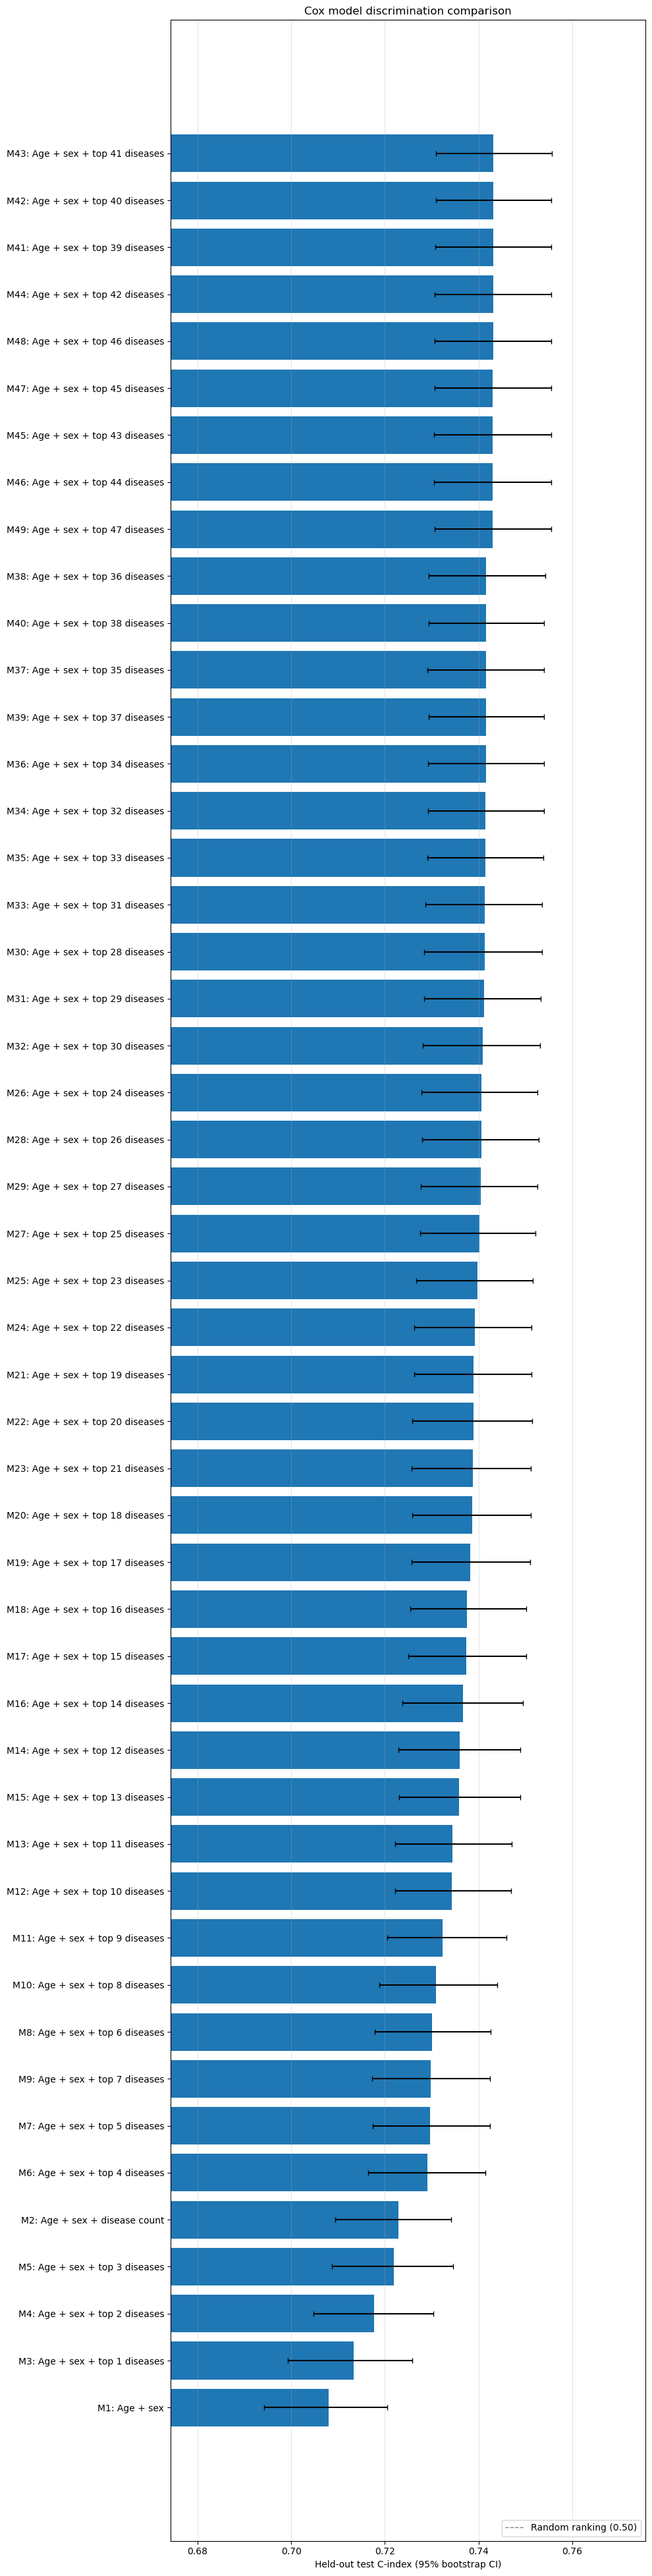

In [30]:
# Visual comparison of held-out C-index across model specifications
# The vertical line at 0.50 represents random risk ranking.
# Prefer a model with strong test C-index, a small train-test optimism gap,
# and a parsimonious number of disease predictors.

try:
    import matplotlib.pyplot as plt

    plot_df = cox_model_comparison_df.sort_values(
        "test_c_index_point_estimate",
        ascending=True,
    ).copy()

    c_index = plot_df["test_c_index_point_estimate"].to_numpy()
    ci_low = plot_df["test_c_index_ci_low"].to_numpy()
    ci_high = plot_df["test_c_index_ci_high"].to_numpy()

    # Plot error bars only where bootstrap CI is available.
    lower_error = np.where(np.isfinite(ci_low), c_index - ci_low, 0)
    upper_error = np.where(np.isfinite(ci_high), ci_high - c_index, 0)

    fig, ax = plt.subplots(figsize=(10, max(4.5, 0.8 * len(plot_df))))
    ax.barh(plot_df["model"], c_index)
    ax.errorbar(
        c_index,
        np.arange(len(plot_df)),
        xerr=[lower_error, upper_error],
        fmt="none",
        ecolor="black",
        capsize=3,
    )
    ax.axvline(0.50, color="gray", linestyle="--", linewidth=1, label="Random ranking (0.50)")
    ax.set_xlabel("Held-out test C-index (95% bootstrap CI)")
    ax.set_title("Cox model discrimination comparison")
    ax.set_xlim(max(0.45, np.nanmin(c_index - lower_error) - 0.02), min(1.0, np.nanmax(c_index + upper_error) + 0.02))
    ax.grid(axis="x", alpha=0.3)
    ax.legend(loc="lower right")
    fig.tight_layout()

    plot_file = output_dir / "cox_model_comparison_test_cindex.png"
    fig.savefig(plot_file, dpi=300, bbox_inches="tight")
    print(f"Saved C-index comparison plot to: {plot_file}")
    plt.show()

except Exception as exc:
    print("C-index comparison plot skipped:", exc)

Full model used for comparison: M_age_sex_top_47_diseases (47 diseases)


,model,n_selected_diseases,train_c_index,test_c_index_point_estimate,test_c_index_ci_low,test_c_index_ci_high,delta_test_c_index_vs_age_sex,improvement_over_age_sex_supported
48,M49: Age + sex + All diseases (n=47),47,0.741478,0.743017,0.730600,0.755439,0.034988,Yes
21,M22: Age + sex + top 20 diseases,20,0.736680,0.738915,0.725839,0.751411,0.030886,Yes
11,M12: Age + sex + top 10 diseases,10,0.731909,0.734299,0.722145,0.746983,0.026270,Yes
6,M7: Age + sex + top 5 diseases,5,0.724335,0.729572,0.717356,0.742461,0.021543,Yes
1,M2: Age + sex + disease count,1,0.714998,0.722857,0.709368,0.734153,0.014828,Yes
2,M3: Age + sex + top 1 diseases,1,0.708549,0.713277,0.699301,0.725886,0.005249,Yes
0,M1: Age + sex,0,0.699911,0.708029,0.694266,0.720455,0.000000,Uncertain


Saved compact C-index comparison plot to: cox_survival_analysis_2012_cluster1_results/cox_model_comparison_compact_cindex.png


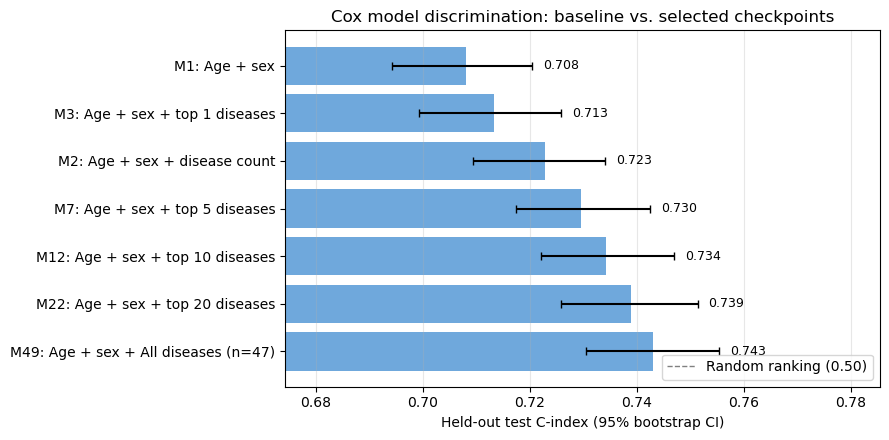

In [31]:
# Compact comparison: baseline vs +top1 vs +disease_count vs a few checkpoints vs full model
# Reuses cox_model_comparison_df computed in the previous section, no refitting needed.

selected_model_keys = [
    "M1_age_sex",
    "M_age_sex_top_1_diseases",
    "M2_age_sex_disease_count",
    "M_age_sex_top_5_diseases",
    "M_age_sex_top_10_diseases",
    "M_age_sex_top_20_diseases",
]

max_n_diseases = cox_model_comparison_df["n_selected_diseases"].max()
full_model_key = cox_model_comparison_df.loc[
    cox_model_comparison_df["n_selected_diseases"] == max_n_diseases, "model_key"
].iloc[0]
selected_model_keys.append(full_model_key)

compact_plot_df = cox_model_comparison_df[
    cox_model_comparison_df["model_key"].isin(selected_model_keys)
].copy()

compact_plot_df["_order"] = compact_plot_df["model_key"].apply(
    lambda k: selected_model_keys.index(k)
)
compact_plot_df = compact_plot_df.sort_values("_order", ascending=False).drop(columns="_order")

# Rename the full-candidate model for display: keep the "M##" prefix,
# but replace "top N diseases" with "All diseases (n=N)".
full_model_number_prefix = compact_plot_df.loc[
    compact_plot_df["model_key"] == full_model_key, "model"
].iloc[0].split(":")[0]  # e.g. "M48"

compact_plot_df.loc[compact_plot_df["model_key"] == full_model_key, "model"] = (
    f"{full_model_number_prefix}: Age + sex + All diseases (n={max_n_diseases})"
)

print(f"Full model used for comparison: {full_model_key} ({max_n_diseases} diseases)")
display(compact_plot_df[[
    "model", "n_selected_diseases", "train_c_index",
    "test_c_index_point_estimate", "test_c_index_ci_low", "test_c_index_ci_high",
    "delta_test_c_index_vs_age_sex", "improvement_over_age_sex_supported",
]])

try:
    import matplotlib.pyplot as plt

    c_index = compact_plot_df["test_c_index_point_estimate"].to_numpy()
    ci_low = compact_plot_df["test_c_index_ci_low"].to_numpy()
    ci_high = compact_plot_df["test_c_index_ci_high"].to_numpy()

    lower_error = np.where(np.isfinite(ci_low), c_index - ci_low, 0)
    upper_error = np.where(np.isfinite(ci_high), ci_high - c_index, 0)

    fig, ax = plt.subplots(figsize=(9, 4.5))
    ax.barh(compact_plot_df["model"], c_index, color="#6fa8dc")
    ax.errorbar(
        c_index,
        np.arange(len(compact_plot_df)),
        xerr=[lower_error, upper_error],
        fmt="none",
        ecolor="black",
        capsize=3,
    )

    # Add C-index value labels just past the upper error bar of each row.
    for i, (value, upper_err) in enumerate(zip(c_index, upper_error)):
        label_x = value + upper_err + 0.002
        ax.text(
            label_x, i, f"{value:.3f}",
            va="center", ha="left", fontsize=9, color="black",
        )

    ax.axvline(0.50, color="gray", linestyle="--", linewidth=1, label="Random ranking (0.50)")
    ax.set_xlabel("Held-out test C-index (95% bootstrap CI)")
    ax.set_title("Cox model discrimination: baseline vs. selected checkpoints")
    ax.set_xlim(
        max(0.45, np.nanmin(c_index - lower_error) - 0.02),
        min(1.0, np.nanmax(c_index + upper_error) + 0.03),  # extra room for labels
    )
    ax.grid(axis="x", alpha=0.3)
    ax.legend(loc="lower right")
    fig.tight_layout()

    compact_plot_file = output_dir / "cox_model_comparison_compact_cindex.png"
    fig.savefig(compact_plot_file, dpi=300, bbox_inches="tight")
    print(f"Saved compact C-index comparison plot to: {compact_plot_file}")
    plt.show()

except Exception as exc:
    print("Compact C-index comparison plot skipped:", exc)


In [32]:
# New cell: Repeated stratified k-fold CV for the FIXED final Cox model
# (age + sex + the 47 diseases selected by the original 80/20 single-split Section 5).
# Section 5 above is untouched -- this only re-evaluates performance of the
# already-decided model spec using a more robust CV scheme.
# The fold splits generated here are reused later for the RSF comparison.

def make_stratified_kfold_masks(base_mask, event_values, n_splits=5, n_repeats=5, seed=42):
    """
    Returns a list of (train_mask, test_mask) tuples.
    n_splits controls the per-fold train/test ratio (5 -> 80/20).
    n_repeats reruns the whole k-fold with new shuffles to reduce
    the influence of any single split.
    """
    base_mask = np.asarray(base_mask, dtype=bool)
    event_values = np.asarray(event_values, dtype=bool)
    eligible_idx = np.where(base_mask)[0]

    splits = []
    for rep in range(n_repeats):
        rng = np.random.default_rng(seed + rep)
        event_idx = eligible_idx[event_values[eligible_idx]].copy()
        censored_idx = eligible_idx[~event_values[eligible_idx]].copy()
        rng.shuffle(event_idx)
        rng.shuffle(censored_idx)

        event_folds = np.array_split(event_idx, n_splits)
        censored_folds = np.array_split(censored_idx, n_splits)

        for fold in range(n_splits):
            test_idx = np.concatenate([event_folds[fold], censored_folds[fold]])
            train_idx = np.concatenate(
                [event_folds[i] for i in range(n_splits) if i != fold]
                + [censored_folds[i] for i in range(n_splits) if i != fold]
            )
            train_mask = np.zeros(len(base_mask), dtype=bool)
            test_mask = np.zeros(len(base_mask), dtype=bool)
            train_mask[train_idx] = True
            test_mask[test_idx] = True
            splits.append({"rep": rep, "fold": fold, "train_mask": train_mask, "test_mask": test_mask})
    return splits


# --- Settings ---
n_splits_final_cv = 5
n_repeats_final_cv = 5     # 25 folds total; each fold fits only ONE model (fast)
seed_final_cv = 42

# Fixed feature set: the 46-disease model already decided by Section 5.
final_predictor_cols = final_model_spec["predictor_cols"]   # age+sex + 46 diseases
print(f"Fixed model spec for CV: {len(final_predictor_cols)} predictors "
      f"({len(candidate_diseases)} diseases + age/sex).")

X_final_df = pd.concat([adjusted_covariate_df, baseline_feature_df], axis=1)
X_final_df = X_final_df[final_predictor_cols].astype(float)

time_all = duration_days.to_numpy()
event_all = event.to_numpy()

# Reusable fold splits -- store these for the later RSF comparison so RSF is
# evaluated on the EXACT same folds as Cox.
final_cv_splits = make_stratified_kfold_masks(
    base_mask=full_model_mask_np,
    event_values=event_all,
    n_splits=n_splits_final_cv,
    n_repeats=n_repeats_final_cv,
    seed=seed_final_cv,
)
print(f"Total folds: {len(final_cv_splits)} "
      f"({n_splits_final_cv} splits x {n_repeats_final_cv} repeats)")

# --- Fit the fixed Cox model on each fold, evaluate on the held-out fold ---
cox_final_cv_records = []

for split in final_cv_splits:
    fold_train_mask = split["train_mask"]
    fold_test_mask = split["test_mask"]

    cox_fit_df = fit_cox_model(
        time=time_all[fold_train_mask],
        event=event_all[fold_train_mask],
        X=X_final_df.to_numpy()[fold_train_mask],
        feature_names=final_predictor_cols,
    )
    if cox_fit_df is None:
        print(f"Rep {split['rep']} Fold {split['fold']}: Cox model failed to fit, skipped.")
        continue

    coef_map = cox_fit_df.set_index("feature")["coef"].to_dict()
    coef_vector = np.array([coef_map.get(c, 0.0) for c in final_predictor_cols], dtype=float)

    risk_test = X_final_df.to_numpy()[fold_test_mask] @ coef_vector
    test_c = concordance_index_censored(time_all[fold_test_mask], event_all[fold_test_mask], risk_test)

    cox_final_cv_records.append({
        "rep": split["rep"],
        "fold": split["fold"],
        "test_c_index": test_c,
    })

cox_final_cv_df = pd.DataFrame(cox_final_cv_records)

cox_final_cv_summary = {
    "model": f"Cox (age+sex+{len(candidate_diseases)} diseases)",
    "n_folds": len(cox_final_cv_df),
    "mean_c_index": cox_final_cv_df["test_c_index"].mean(),
    "std_c_index": cox_final_cv_df["test_c_index"].std(),
    "ci_low": cox_final_cv_df["test_c_index"].quantile(0.025),
    "ci_high": cox_final_cv_df["test_c_index"].quantile(0.975),
}

print("\nRepeated k-fold CV summary for the fixed final Cox model:")
print(cox_final_cv_summary)

cox_final_cv_file = output_dir / "cox_final_model_repeated_kfold_cindex.csv"
cox_final_cv_file = safe_to_csv(cox_final_cv_df, cox_final_cv_file)
print(f"Saved fold-level results to: {cox_final_cv_file}")

Fixed model spec for CV: 49 predictors (47 diseases + age/sex).
Total folds: 25 (5 splits x 5 repeats)

Repeated k-fold CV summary for the fixed final Cox model:
{'model': 'Cox (age+sex+47 diseases)', 'n_folds': 25, 'mean_c_index': np.float64(0.7399522203954784), 'std_c_index': 0.004437747409655552, 'ci_low': np.float64(0.7319535508102877), 'ci_high': np.float64(0.7458658254311077)}
Saved fold-level results to: cox_survival_analysis_2012_cluster1_results/cox_final_model_repeated_kfold_cindex.csv


In [33]:
import gc

# One-time lightweight RSF hyperparameter search.
# Memory-safe version: single-threaded forests, smaller n_estimators during
# search, explicit cleanup after each run. Suited for machines with limited
# RAM (e.g. 8GB total).

from sksurv.ensemble import RandomSurvivalForest
from sksurv.util import Surv
from sklearn.model_selection import ParameterGrid

tune_train_mask, tune_val_mask = make_train_test_mask(
    base_mask=section5_train_mask_np,   
    event_values=event_all,
    test_size=0.25,
    seed=99,
)

# Smaller grid to start -- fewer combinations means fewer forests to build.
# You can expand this later once you confirm memory stays stable.
param_grid = {
    "min_samples_leaf": [5, 10, 15, 20, 30],
    "max_features": ["sqrt", 0.5],
}

tuning_records = []
n_combos = len(list(ParameterGrid(param_grid)))
print(f"Will fit {n_combos} RSF models for tuning (one at a time, low memory mode).")

for i, params in enumerate(ParameterGrid(param_grid)):
    y_tune_train = Surv.from_arrays(
        event=event_all[tune_train_mask], time=time_all[tune_train_mask]
    )

    rsf_tune = RandomSurvivalForest(
        n_estimators=150,       # smaller than final model (500) to save memory/time during search
        min_samples_leaf=params["min_samples_leaf"],
        max_features=params["max_features"],
        n_jobs=1,               # single-threaded: avoids multiple parallel copies of the forest in memory
        random_state=42,
    )
    rsf_tune.fit(X_final_df.to_numpy()[tune_train_mask], y_tune_train)

    val_risk = rsf_tune.predict(X_final_df.to_numpy()[tune_val_mask])
    val_c = concordance_index_censored(
        time_all[tune_val_mask], event_all[tune_val_mask], val_risk
    )
    tuning_records.append({**params, "val_c_index": val_c})
    print(f"[{i+1}/{n_combos}]", params, f"-> val C-index = {val_c:.4f}")

    # Explicitly free memory before starting the next forest.
    del rsf_tune, y_tune_train, val_risk
    gc.collect()

tuning_df = pd.DataFrame(tuning_records).sort_values("val_c_index", ascending=False)

tuning_file = output_dir / "rsf_hyperparameter_tuning_results.csv"
tuning_file = safe_to_csv(tuning_df, tuning_file)
print(f"\nSaved tuning results to: {tuning_file}")
display(tuning_df)

best_params_rsf = tuning_df.iloc[0][["min_samples_leaf", "max_features"]].to_dict()
print("\nBest params found (will be used in the RSF CV below):", best_params_rsf)

Will fit 10 RSF models for tuning (one at a time, low memory mode).
[1/10] {'max_features': 'sqrt', 'min_samples_leaf': 5} -> val C-index = 0.7268
[2/10] {'max_features': 'sqrt', 'min_samples_leaf': 10} -> val C-index = 0.7251
[3/10] {'max_features': 'sqrt', 'min_samples_leaf': 15} -> val C-index = 0.7237
[4/10] {'max_features': 'sqrt', 'min_samples_leaf': 20} -> val C-index = 0.7227
[5/10] {'max_features': 'sqrt', 'min_samples_leaf': 30} -> val C-index = 0.7206
[6/10] {'max_features': 0.5, 'min_samples_leaf': 5} -> val C-index = 0.7203
[7/10] {'max_features': 0.5, 'min_samples_leaf': 10} -> val C-index = 0.7206
[8/10] {'max_features': 0.5, 'min_samples_leaf': 15} -> val C-index = 0.7205
[9/10] {'max_features': 0.5, 'min_samples_leaf': 20} -> val C-index = 0.7200
[10/10] {'max_features': 0.5, 'min_samples_leaf': 30} -> val C-index = 0.7195

Saved tuning results to: cox_survival_analysis_2012_cluster1_results/rsf_hyperparameter_tuning_results.csv


,max_features,min_samples_leaf,val_c_index
0,sqrt,5,0.726768
1,sqrt,10,0.725143
2,sqrt,15,0.723717
3,sqrt,20,0.722725
6,0.5,10,0.720599
4,sqrt,30,0.720560
7,0.5,15,0.720483
5,0.5,5,0.720263
8,0.5,20,0.720008
9,0.5,30,0.719482



Best params found (will be used in the RSF CV below): {'min_samples_leaf': 5, 'max_features': 'sqrt'}


Saved plot to: cox_survival_analysis_2012_cluster1_results/multivariable_disease_contribution_and_hr.png


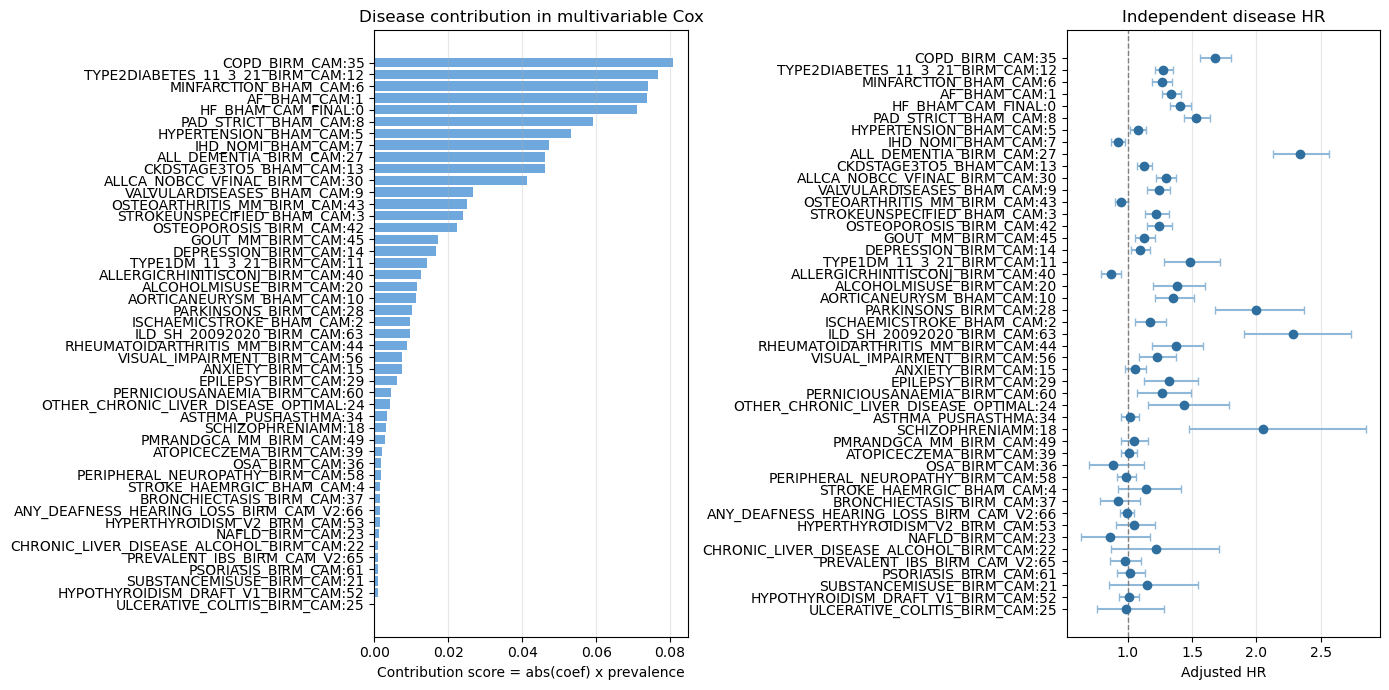

,feature,coef,hr,ci_low,ci_high,p_value,se,n,n_event,is_disease_feature,prevalence,n_exposed_event,n_exposed,contribution_score
0,COPD_BIRM_CAM:35,0.516344,1.675889,1.561265,1.798928,2.725656e-46,0.036147,14406,6466,True,0.156254,1328.0,2251,0.080681
1,TYPE2DIABETES_11_3_21_BIRM_CAM:12,0.244768,1.277325,1.208953,1.349564,2.767955e-18,0.028068,14406,6466,True,0.314036,2109.0,4524,0.076866
2,MINFARCTION_BHAM_CAM:6,0.235108,1.265045,1.191612,1.343004,1.300752e-14,0.030511,14406,6466,True,0.314730,1916.0,4534,0.073996
3,AF_BHAM_CAM:1,0.289721,1.336055,1.263419,1.412866,3.039270e-24,0.028520,14406,6466,True,0.254269,1960.0,3663,0.073667
4,HF_BHAM_CAM_FINAL:0,0.342058,1.407842,1.328035,1.492445,1.509141e-30,0.029774,14406,6466,True,0.207552,1610.0,2990,0.070995
5,PAD_STRICT_BHAM_CAM:8,0.427677,1.533691,1.436039,1.637983,3.474879e-37,0.033566,14406,6466,True,0.138484,1123.0,1995,0.059226
6,HYPERTENSION_BHAM_CAM:5,0.074904,1.077781,1.017493,1.141640,1.075713e-02,0.029368,14406,6466,True,0.711648,4782.0,10252,0.053305
7,IHD_NOMI_BHAM_CAM:7,-0.079808,0.923294,0.873867,0.975516,4.468338e-03,0.028071,14406,6466,True,0.593017,3608.0,8543,0.047327
8,ALL_DEMENTIA_BIRM_CAM:27,0.848810,2.336863,2.129421,2.564514,1.251375e-71,0.047428,14406,6466,True,0.054491,539.0,785,0.046253
9,CKDSTAGE3TO5_BHAM_CAM:13,0.121529,1.129223,1.072446,1.189005,3.886407e-06,0.026320,14406,6466,True,0.380536,2911.0,5482,0.046246


In [34]:
# Plot multivariable disease contribution
# adjusted HR shows independent association; contribution_score combines effect size and prevalence.

try:
    import matplotlib.pyplot as plt

    plot_df = multivariable_disease_contribution_df.sort_values("contribution_score", ascending=True)

    fig, axes = plt.subplots(1, 2, figsize=(14, 7))

    axes[0].barh(plot_df["feature"], plot_df["contribution_score"], color="#6fa8dc")
    axes[0].set_xlabel("Contribution score = abs(coef) x prevalence")
    axes[0].set_title("Disease contribution in multivariable Cox")
    axes[0].grid(axis="x", alpha=0.3)

    axes[1].errorbar(
        plot_df["hr"],
        np.arange(len(plot_df)),
        xerr=[plot_df["hr"] - plot_df["ci_low"], plot_df["ci_high"] - plot_df["hr"]],
        fmt="o",
        color="#2f6f9f",
        ecolor="#8fb8d9",
        capsize=3,
    )
    axes[1].axvline(1, color="gray", linestyle="--", linewidth=1)
    axes[1].set_yticks(np.arange(len(plot_df)))
    axes[1].set_yticklabels(plot_df["feature"])
    axes[1].set_xlabel("Adjusted HR")
    axes[1].set_title("Independent disease HR")
    axes[1].grid(axis="x", alpha=0.3)

    fig.tight_layout()
    plot_file = output_dir / "multivariable_disease_contribution_and_hr.png"
    fig.savefig(plot_file, dpi=300, bbox_inches="tight")
    print(f"Saved plot to: {plot_file}")
    plt.show()
except Exception as exc:
    print("Plot skipped:", exc)

multivariable_disease_contribution_df.head(20)


In [35]:
# Final combined reporting table
# This joins survival differences, univariate HR, age-sex adjusted HR, and multivariable contribution.

final_report_df = survival_by_disease_df[[
    "feature",
    "n_with_disease",
    "n_events_with_disease",
    "survival_5y_with",
    "survival_10y_with",
    "survival_10y_without",
    "survival_difference_10y",
    "mortality_10y_with",
    "mortality_difference_10y",
]].merge(
    cox_result_df[["feature", "hr", "p_value"]].rename(columns={
        "hr": "univariate_hr",
        "p_value": "univariate_p_value",
    }),
    on="feature",
    how="left",
).merge(
    age_sex_adjusted_cox_df[["feature", "hr", "p_value"]].rename(columns={
        "hr": "age_sex_adjusted_hr",
        "p_value": "age_sex_adjusted_p_value",
    }),
    on="feature",
    how="left",
).merge(
    multivariable_disease_contribution_df[["feature", "hr", "p_value", "contribution_score"]].rename(columns={
        "hr": "multivariable_hr",
        "p_value": "multivariable_p_value",
    }),
    on="feature",
    how="left",
)

percent_cols = [
    "survival_5y_with",
    "survival_10y_with",
    "survival_10y_without",
    "survival_difference_10y",
    "mortality_10y_with",
    "mortality_difference_10y",
]
for col in percent_cols:
    final_report_df[col] = final_report_df[col] * 100

final_report_df = final_report_df.sort_values(
    ["contribution_score", "age_sex_adjusted_p_value"],
    ascending=[False, True],
    na_position="last",
).reset_index(drop=True)

final_report_file = output_dir / "final_survival_and_cox_report.csv"
final_report_file = safe_to_csv(final_report_df, final_report_file)

print(f"Saved final report to: {final_report_file}")
final_report_df.head(25)


Saved final report to: cox_survival_analysis_2012_cluster1_results/final_survival_and_cox_report.csv


,feature,n_with_disease,n_events_with_disease,survival_5y_with,survival_10y_with,survival_10y_without,survival_difference_10y,mortality_10y_with,mortality_difference_10y,univariate_hr,univariate_p_value,age_sex_adjusted_hr,age_sex_adjusted_p_value,multivariable_hr,multivariable_p_value,contribution_score
0,COPD_BIRM_CAM:35,2251,1328,60.146293,31.923661,49.858998,-17.935336,68.076339,17.935336,1.648707,3.495455e-59,1.667595,1.106486e-61,1.675889,2.725656e-46,0.080681
1,TYPE2DIABETES_11_3_21_BIRM_CAM:12,4524,2109,71.276923,45.801994,47.614799,-1.812805,54.198006,1.812805,1.037185,1.687284e-01,1.225730,2.759238e-14,1.277325,2.767955e-18,0.076866
2,MINFARCTION_BHAM_CAM:6,4534,1916,73.724170,50.307591,45.502621,4.804970,49.692409,-4.804970,0.872949,6.090129e-07,1.030540,2.792214e-01,1.265045,1.300752e-14,0.073996
3,AF_BHAM_CAM:1,3663,1960,63.227191,36.447858,50.543275,-14.095417,63.552142,14.095417,1.505809,1.434431e-51,1.232078,1.846684e-14,1.336055,3.039270e-24,0.073667
4,HF_BHAM_CAM_FINAL:0,2990,1610,61.957187,36.427944,49.738734,-13.310790,63.572056,13.310790,1.514064,4.589486e-47,1.413769,4.245536e-33,1.407842,1.509141e-30,0.070995
5,PAD_STRICT_BHAM_CAM:8,1995,1123,63.069319,34.458219,49.059318,-14.601099,65.541781,14.601099,1.505266,1.390617e-35,1.516662,1.056318e-36,1.533691,3.474879e-37,0.059226
6,HYPERTENSION_BHAM_CAM:5,10252,4782,71.076971,45.017178,52.067483,-7.050304,54.982822,7.050304,1.173633,1.610283e-08,1.047225,1.059175e-01,1.077781,1.075713e-02,0.053305
7,IHD_NOMI_BHAM_CAM:7,8543,3608,74.305241,50.488516,41.825558,8.662958,49.511484,-8.662958,0.775740,3.873763e-24,0.858797,2.252963e-09,0.923294,4.468338e-03,0.047327
8,ALL_DEMENTIA_BIRM_CAM:27,785,539,32.012196,5.377298,48.886758,-43.509460,94.622702,43.509460,3.654407,8.805273e-177,2.143583,2.300426e-60,2.336863,1.251375e-71,0.046253
9,CKDSTAGE3TO5_BHAM_CAM:13,5482,2911,64.083948,36.948619,53.056741,-16.108122,63.051381,16.108122,1.576249,8.496686e-74,1.129330,2.361471e-06,1.129223,3.886407e-06,0.046246
